# Stock Market Exploratory Data Analysis

Notebook này tập trung vào **khám phá dữ liệu** thay vì xây dựng một hệ thống báo cáo phức tạp.

Mục tiêu:

- kiểm tra cấu trúc và chất lượng dữ liệu cổ phiếu;
- phân tích giá, lợi nhuận, biến động, drawdown và khối lượng;
- kiểm tra riêng các ngày `Volume = 0`;
- mô tả lợi nhuận tương lai tại các chân trời 1, 5, 10, 20 và 30 phiên;
- so sánh mẫu VN30 với mẫu 20 cổ phiếu Nasdaq.

Notebook không huấn luyện mô hình và không dùng EDA để tuyên bố chân trời dự báo tối ưu.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from lunar_vn import solar_to_lunar

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = Path.cwd()
if not (ROOT / "Raw Data").exists():
    ROOT = ROOT.parent
if not (ROOT / "Raw Data").exists():
    raise FileNotFoundError("Không tìm thấy thư mục 'Raw Data'.")

CONFIG = {
    "SELECTED_MARKET": "VN",
    "SELECTED_TICKER": "FPT",
    "START_DATE": "2020-01-01",
    "END_DATE": "2026-09-01",
    "TRAIN_END": "2023-12-31",
    "VALIDATION_END": "2024-12-31",
    "HORIZONS": [1, 5, 10, 20, 30],
    "DROP_ZERO_VOLUME": True,
}

RAW_DIR = ROOT / "Raw Data"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Selected stock: {CONFIG['SELECTED_MARKET']}-{CONFIG['SELECTED_TICKER']}")

Project root: C:\Users\Hoang Phu\Downloads\HCMUT\Final Year\P4AI&DS\BTL\P4AIDS---Stock
Selected stock: VN-FPT


## 1. Khám phá dữ liệu đầu vào

Trước khi làm sạch, ta kiểm tra số file, schema, số dòng và khoảng thời gian của từng mã.

In [2]:
REQUIRED_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
PRICE_COLUMNS = ["Open", "High", "Low", "Close", "Adj Close"]
NUMERIC_COLUMNS = PRICE_COLUMNS + ["Volume", "Dividends", "Stock Splits"]

def discover_files(raw_dir):
    records = []
    for path in sorted(raw_dir.rglob("*.csv")):
        upper_parts = [part.upper() for part in path.parts]
        market = "VN" if "VN" in upper_parts else "US" if "US" in upper_parts else "UNKNOWN"
        ticker = path.stem.upper().replace(".VN", "")
        records.append({"market": market, "ticker": ticker, "path": path, "file": path.name})
    return pd.DataFrame(records)

def profile_files(files):
    records = []
    for item in files.itertuples(index=False):
        try:
            frame = pd.read_csv(item.path)
            frame.columns = frame.columns.str.strip()
            dates = pd.to_datetime(frame["Date"].astype("string").str[:10], errors="coerce") if "Date" in frame else pd.Series(dtype="datetime64[ns]")
            missing = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
            records.append({
                "Thị trường": item.market,
                "Mã": item.ticker,
                "Số dòng": len(frame),
                "Ngày đầu": dates.min(),
                "Ngày cuối": dates.max(),
                "Thiếu cột": ", ".join(missing) if missing else "",
                "Schema": "OK" if not missing else "ERROR",
            })
        except Exception as exc:
            records.append({
                "Thị trường": item.market,
                "Mã": item.ticker,
                "Schema": f"ERROR: {type(exc).__name__}",
            })
    return pd.DataFrame(records)

FILES = discover_files(RAW_DIR)
FILE_PROFILE = profile_files(FILES)

display(FILES.groupby("market").size().rename("Số file").to_frame())
display(FILE_PROFILE)
print(f"Tổng số file: {len(FILES)} | File lỗi schema: {(FILE_PROFILE['Schema'] != 'OK').sum()}")

,Số file
market,
US,20
VN,30


,Thị trường,Mã,Số dòng,Ngày đầu,Ngày cuối,Thiếu cột,Schema
0,US,AAPL,1674,2020-01-02,2026-08-31,,OK
1,US,ADBE,1674,2020-01-02,2026-08-31,,OK
2,US,AMD,1674,2020-01-02,2026-08-31,,OK
3,US,AMGN,1674,2020-01-02,2026-08-31,,OK
4,US,AMZN,1674,2020-01-02,2026-08-31,,OK
5,US,AVGO,1674,2020-01-02,2026-08-31,,OK
6,US,COST,1674,2020-01-02,2026-08-31,,OK
7,US,CSCO,1674,2020-01-02,2026-08-31,,OK
8,US,GOOG,1674,2020-01-02,2026-08-31,,OK
9,US,GOOGL,1674,2020-01-02,2026-08-31,,OK


Tổng số file: 50 | File lỗi schema: 0


## 2. Đọc, kiểm tra và làm sạch

Quy tắc làm sạch được giữ ngắn và minh bạch:

- parse ngày, chuyển các cột số và sắp xếp theo thời gian;
- ngày trùng giữ bản ghi cuối;
- loại dòng thiếu giá, giá không dương hoặc quan hệ OHLC sai;
- loại volume thiếu/âm; `Volume = 0` được thống kê riêng rồi loại theo cấu hình;
- số dòng ngoài khoảng phân tích được báo riêng, không tính là lỗi chất lượng.

Các số lượng lỗi có thể chồng lấn nên không cộng trực tiếp từng loại.

In [3]:
def parse_dates(series):
    return pd.to_datetime(series.astype("string").str.strip().str[:10], errors="coerce")

def assign_split(dates):
    return np.select(
        [
            dates <= pd.Timestamp(CONFIG["TRAIN_END"]),
            dates <= pd.Timestamp(CONFIG["VALIDATION_END"]),
        ],
        ["Train", "Validation"],
        default="Test",
    )

def load_stock(path, market, ticker):
    frame = pd.read_csv(path)
    frame.columns = frame.columns.str.strip()

    missing_columns = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Thiếu cột bắt buộc: {missing_columns}")

    for column in ["Dividends", "Stock Splits"]:
        if column not in frame.columns:
            frame[column] = 0.0

    original_rows = len(frame)
    missing_cells_before_conversion = int(frame.isna().sum().sum())

    frame["Date"] = parse_dates(frame["Date"])
    for column in NUMERIC_COLUMNS:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    invalid_dates = int(frame["Date"].isna().sum())
    duplicate_dates = int(frame["Date"].notna().sum() - frame.loc[frame["Date"].notna(), "Date"].nunique())

    frame = (
        frame.sort_values("Date", kind="stable", na_position="last")
        .drop_duplicates("Date", keep="last")
        .reset_index(drop=True)
    )

    start = pd.Timestamp(CONFIG["START_DATE"])
    end = pd.Timestamp(CONFIG["END_DATE"])
    in_period = frame["Date"].between(start, end)
    outside_period = int((frame["Date"].notna() & ~in_period).sum())
    scoped = frame.loc[in_period].copy()

    prices = scoped[PRICE_COLUMNS]
    missing_price = prices.isna().any(axis=1)
    nonpositive_price = (prices <= 0).any(axis=1)
    invalid_ohlc = (
        (scoped["High"] < scoped[["Open", "Close", "Low"]].max(axis=1))
        | (scoped["Low"] > scoped[["Open", "Close", "High"]].min(axis=1))
    )
    invalid_volume = scoped["Volume"].isna() | scoped["Volume"].lt(0)
    zero_volume = scoped["Volume"].eq(0)

    bad_row = missing_price | nonpositive_price | invalid_ohlc | invalid_volume
    if CONFIG["DROP_ZERO_VOLUME"]:
        bad_row |= zero_volume

    clean = scoped.loc[~bad_row].copy().reset_index(drop=True)
    clean["Split"] = assign_split(clean["Date"])

    quality = {
        "Thị trường": market,
        "Mã": ticker,
        "Số dòng gốc": original_rows,
        "Ngày không hợp lệ": invalid_dates,
        "Ngày trùng": duplicate_dates,
        "Ô thiếu trước ép kiểu": missing_cells_before_conversion,
        "Dòng thiếu giá": int(missing_price.sum()),
        "Dòng giá không dương": int(nonpositive_price.sum()),
        "Dòng OHLC không hợp lệ": int(invalid_ohlc.sum()),
        "Dòng volume thiếu/âm": int(invalid_volume.sum()),
        "Dòng Volume=0": int(zero_volume.sum()),
        "Dòng ngoài phạm vi": outside_period,
        "Dòng loại do chất lượng": int(bad_row.sum()),
        "Dòng sạch": len(clean),
    }
    return scoped, clean, quality

In [4]:
selected_market = CONFIG["SELECTED_MARKET"].upper()
selected_ticker = CONFIG["SELECTED_TICKER"].upper().replace(".VN", "")

selected_file = FILES[
    FILES["market"].eq(selected_market) & FILES["ticker"].eq(selected_ticker)
]
if selected_file.empty:
    raise FileNotFoundError(f"Không tìm thấy {selected_market}-{selected_ticker}")

selected_info = selected_file.iloc[0]
SELECTED_RAW, SELECTED_CLEAN, SELECTED_QUALITY = load_stock(
    selected_info["path"], selected_market, selected_ticker
)

display(pd.DataFrame([SELECTED_QUALITY]))

DATE_GAPS = SELECTED_CLEAN[["Date"]].copy()
DATE_GAPS["Khoảng cách ngày"] = DATE_GAPS["Date"].diff().dt.days
DATE_GAPS = DATE_GAPS[DATE_GAPS["Khoảng cách ngày"] > 4].sort_values("Khoảng cách ngày", ascending=False)

print("Các khoảng cách lớn hơn 4 ngày giữa hai quan sát sạch:")
display(DATE_GAPS.head(20))

,Thị trường,Mã,Số dòng gốc,Ngày không hợp lệ,Ngày trùng,Ô thiếu trước ép kiểu,Dòng thiếu giá,Dòng giá không dương,Dòng OHLC không hợp lệ,Dòng volume thiếu/âm,Dòng Volume=0,Dòng ngoài phạm vi,Dòng loại do chất lượng,Dòng sạch
0,VN,FPT,1738,0,0,0,0,0,1,0,119,0,120,1618


Các khoảng cách lớn hơn 4 ngày giữa hai quan sát sạch:


,Date,Khoảng cách ngày
1224,2025-02-03,10.0000
486,2022-02-07,10.0000
1486,2026-02-23,10.0000
269,2021-02-17,9.0000
726,2023-01-27,8.0000
985,2024-02-15,8.0000
15,2020-01-30,8.0000
362,2021-07-09,7.0000
1285,2025-05-05,6.0000
422,2021-10-28,6.0000




Với cấu hình hiện tại, FPT giữ lại 1.618 dòng và loại 6,90% số dòng gốc do chất lượng. Volume bằng 0 là nguyên nhân chính cần audit, trong khi khoảng cách lớn nhất giữa hai quan sát sạch là 10 ngày.

In [5]:
# Kiểm tra riêng các ngày Volume = 0 trước khi các dòng này bị loại.
ZERO_VOLUME_DATES = SELECTED_RAW.loc[
    SELECTED_RAW["Volume"].eq(0),
    ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"],
].copy()

if not ZERO_VOLUME_DATES.empty:
    ZERO_VOLUME_DATES["OHLC phẳng"] = (
        ZERO_VOLUME_DATES[["Open", "High", "Low", "Close"]]
        .nunique(axis=1, dropna=False)
        .eq(1)
    )
else:
    ZERO_VOLUME_DATES["OHLC phẳng"] = pd.Series(dtype="boolean")

ZERO_VOLUME_DATE_LIST = (
    ZERO_VOLUME_DATES[["Date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("Date")
    .reset_index(drop=True)
)
WEEKDAY_VI = {
    0: "Thứ Hai", 1: "Thứ Ba", 2: "Thứ Tư", 3: "Thứ Năm",
    4: "Thứ Sáu", 5: "Thứ Bảy", 6: "Chủ Nhật",
}

ZERO_VOLUME_DATE_LIST["Year"] = ZERO_VOLUME_DATE_LIST["Date"].dt.year
ZERO_VOLUME_DATE_LIST["Month-Day"] = ZERO_VOLUME_DATE_LIST["Date"].dt.strftime("%m-%d")
ZERO_VOLUME_DATE_LIST["Weekday"] = ZERO_VOLUME_DATE_LIST["Date"].dt.dayofweek.map(WEEKDAY_VI)
lunar_dates = ZERO_VOLUME_DATE_LIST["Date"].apply(lambda value: solar_to_lunar(value.date()))
ZERO_VOLUME_DATE_LIST["Year (Lunar)"] = lunar_dates.map(lambda value: value.year)
ZERO_VOLUME_DATE_LIST["Month-Day (Lunar)"] = lunar_dates.map(
    lambda value: f"{value.month:02d}-{value.day:02d}" + (" (nhuận)" if value.leap else "")
)
ZERO_VOLUME_DATE_LIST = ZERO_VOLUME_DATE_LIST[
    ["Year", "Month-Day", "Year (Lunar)", "Month-Day (Lunar)", "Weekday"]
]

print(f"{selected_market}-{selected_ticker} có {len(ZERO_VOLUME_DATES)} ngày Volume=0 trong phạm vi phân tích.")
with pd.option_context("display.max_rows", None):
    display(ZERO_VOLUME_DATE_LIST)

VN-FPT có 119 ngày Volume=0 trong phạm vi phân tích.


,Year,Month-Day,Year (Lunar),Month-Day (Lunar),Weekday
0,2020,01-01,2019,12-07,Thứ Tư
1,2020,01-23,2019,12-29,Thứ Năm
2,2020,01-24,2019,12-30,Thứ Sáu
3,2020,01-27,2020,01-03,Thứ Hai
4,2020,01-28,2020,01-04,Thứ Ba
5,2020,01-29,2020,01-05,Thứ Tư
6,2020,04-02,2020,03-10,Thứ Năm
7,2020,04-30,2020,04-08,Thứ Năm
8,2020,05-01,2020,04-09,Thứ Sáu
9,2020,05-15,2020,04-23,Thứ Sáu


In [6]:
Month_Day_Filter = [
    # Tết Dương lịch & ngày nghỉ bù/liền kề
    '01-01', '01-02', '01-03',
    
    # Kỷ niệm 30/4 - 01/5 & ngày hoán đổi/nghỉ bù
    '04-29', '04-30', '05-01', '05-02', '05-03',
    
    # Quốc khánh 02/9 & các ngày liền kề/nghỉ bù
    '08-31', '09-01', '09-02', '09-03', '09-04'
]
Lunar_Month_Day_Filter = [
    # Tết Nguyên Đán (Cuối năm cũ)
    '12-28', '12-29', '12-30',
    
    # Tết Nguyên Đán (Đầu năm mới)
    '01-01', '01-02', '01-03', '01-04', '01-05',
    
    # Giỗ Tổ Hùng Vương (Chính lễ & nghỉ bù ngày 11/3)
    '03-10', '03-11'
]
Weekday_Filter = [
    'Thứ Bảy',
    'Chủ Nhật'
]
def is_market_closed(row):
    # Priority 1: Nghỉ Lễ Dương lịch
    if row['Month-Day'] in Month_Day_Filter:
        return True
    # Priority 2: Nghỉ Lễ Âm lịch (Tết Âm, Giỗ Tổ)
    if row['Month-Day (Lunar)'] in Lunar_Month_Day_Filter:
        return True
    # Priority 3: Cuối tuần
    if row['Weekday'] in Weekday_Filter:
        return True
    return False


ZERO_VOLUME_DATE_LIST["Market Closed"] = ZERO_VOLUME_DATE_LIST.apply(is_market_closed, axis=1)
display(ZERO_VOLUME_DATE_LIST.loc[~ZERO_VOLUME_DATE_LIST["Market Closed"]])

,Year,Month-Day,Year (Lunar),Month-Day (Lunar),Weekday,Market Closed
9,2020,05-15,2020,04-23,Thứ Sáu,False
10,2020,05-18,2020,04-26,Thứ Hai,False
11,2020,05-20,2020,04-28,Thứ Tư,False
12,2020,06-08,2020,04-17 (nhuận),Thứ Hai,False
13,2020,06-09,2020,04-18 (nhuận),Thứ Ba,False
14,2020,07-10,2020,05-20,Thứ Sáu,False
15,2020,07-15,2020,05-25,Thứ Tư,False
17,2020,09-11,2020,07-24,Thứ Sáu,False
25,2021,02-24,2021,01-13,Thứ Tư,False
29,2021,06-08,2021,04-28,Thứ Ba,False


Những ngày trên có thể coi là missing data vì khi crawl data từ yfinnace về các hàng missing value sẽ được fillna(0) thì có thể các trường hợp trên là missing value.

## 3. Tổng quan mã được chọn

Các feature bên dưới đều sử dụng thông tin tại hoặc trước thời điểm hiện tại. EDA quyết định chỉ sử dụng phần Train.

,Chỉ tiêu,Giá trị
0,Số dòng sạch toàn kỳ,1618
1,Số dòng Train,960
2,Ngày đầu toàn kỳ,2020-01-02 00:00:00
3,Ngày cuối toàn kỳ,2026-08-28 00:00:00
4,Ngày đầu Train,2020-01-02 00:00:00
5,Ngày cuối Train,2023-12-29 00:00:00


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Split,Return_1D,Return_5D,Return_20D,Cumulative_Return,MA20,MA50,Price_vs_MA20,Price_vs_MA50,Volatility_20_Ann,Volume_MA20,RVOL,Running_Max,Drawdown,Abs_Return,Year
0,2020-01-02,"24,154.5039","24,444.5234","24,030.2090","24,278.7969","21,078.9082",2164349,0.0000,0.0000,Train,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,078.9082",0.0000,NaN,2020
1,2020-01-03,"24,403.0918","24,485.9551","23,781.6211","23,864.4824","20,719.2031",4942821,0.0000,0.0000,Train,-0.0171,NaN,NaN,-0.0171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,078.9082",-0.0171,0.0171,2020
2,2020-01-06,"23,657.3262","23,864.4824","23,533.0312","23,615.8945","20,503.3770",2634861,0.0000,0.0000,Train,-0.0104,NaN,NaN,-0.0273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,078.9082",-0.0273,0.0104,2020
3,2020-01-07,"23,740.1895","24,071.6406","23,615.8945","24,071.6406","20,899.0586",2020786,0.0000,0.0000,Train,0.0193,NaN,NaN,-0.0085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,078.9082",-0.0085,0.0193,2020
4,2020-01-08,"23,823.0527","23,905.9141","23,533.0312","23,533.0312","20,431.4336",4379022,0.0000,0.0000,Train,-0.0224,NaN,NaN,-0.0307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"21,078.9082",-0.0307,0.0224,2020


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Split,Return_1D,Return_5D,Return_20D,Cumulative_Return,MA20,MA50,Price_vs_MA20,Price_vs_MA50,Volatility_20_Ann,Volume_MA20,RVOL,Running_Max,Drawdown,Abs_Return,Year
955,2023-12-25,"71,758.0312","72,741.0234","71,682.4219","72,589.7891","69,520.3203",2667482,0.0000,0.0000,Train,0.0148,0.0213,0.0584,2.2981,"68,339.9191","66,588.8753",0.0173,0.0440,0.1615,"2,628,157.5500",1.0150,"71,692.8281",-0.0303,0.0148,2023
956,2023-12-26,"72,967.8672","74,555.7656","72,892.2500","73,497.1641","70,389.3203",4443467,0.0000,0.0000,Train,0.0125,0.0275,0.0670,2.3393,"68,560.7910","66,648.2573",0.0267,0.0561,0.1650,"2,778,208.4000",1.5994,"71,692.8281",-0.0182,0.0125,2023
957,2023-12-27,"73,648.3906","73,950.8516","73,270.3203","73,270.3203","70,172.0703",1793177,0.0000,0.0000,Train,-0.0031,0.0232,0.0567,2.3290,"68,749.0750","66,704.7428",0.0207,0.0520,0.1660,"2,814,868.1000",0.6370,"71,692.8281",-0.0212,0.0031,2023
958,2023-12-28,"73,345.9375","73,345.9375","72,816.6328","73,043.4766","69,954.8125",1582503,0.0000,0.0000,Train,-0.0031,0.0158,0.0511,2.3187,"68,919.2543","66,771.3663",0.0150,0.0477,0.1674,"2,762,907.0500",0.5728,"71,692.8281",-0.0242,0.0031,2023
959,2023-12-29,"73,043.4766","73,345.9375","72,665.4062","72,665.4062","69,592.7344",2468578,0.0000,0.0000,Train,-0.0052,0.0159,0.0400,2.3015,"69,053.2262","66,817.7131",0.0078,0.0415,0.1692,"2,807,594.3000",0.8793,"71,692.8281",-0.0293,0.0052,2023


,count,mean,std,min,25%,50%,75%,max
Adj Close,960.0000,"42,258.1134","15,195.9027","14,532.2188","24,916.2520","46,994.1367","51,603.2832","71,692.8281"
Volume,960.0000,"3,651,361.1385","15,916,299.3269","253,745.0000","1,366,118.0000","2,469,209.0000","3,942,145.5000","415,709,889.0000"
Return_1D,959.0000,0.0014,0.0182,-0.0698,-0.0064,0.0010,0.0094,0.0926
Return_5D,955.0000,0.0072,0.0402,-0.1190,-0.0149,0.0054,0.0276,0.2372
Return_20D,940.0000,0.0296,0.0791,-0.2668,-0.0187,0.0295,0.0732,0.2935


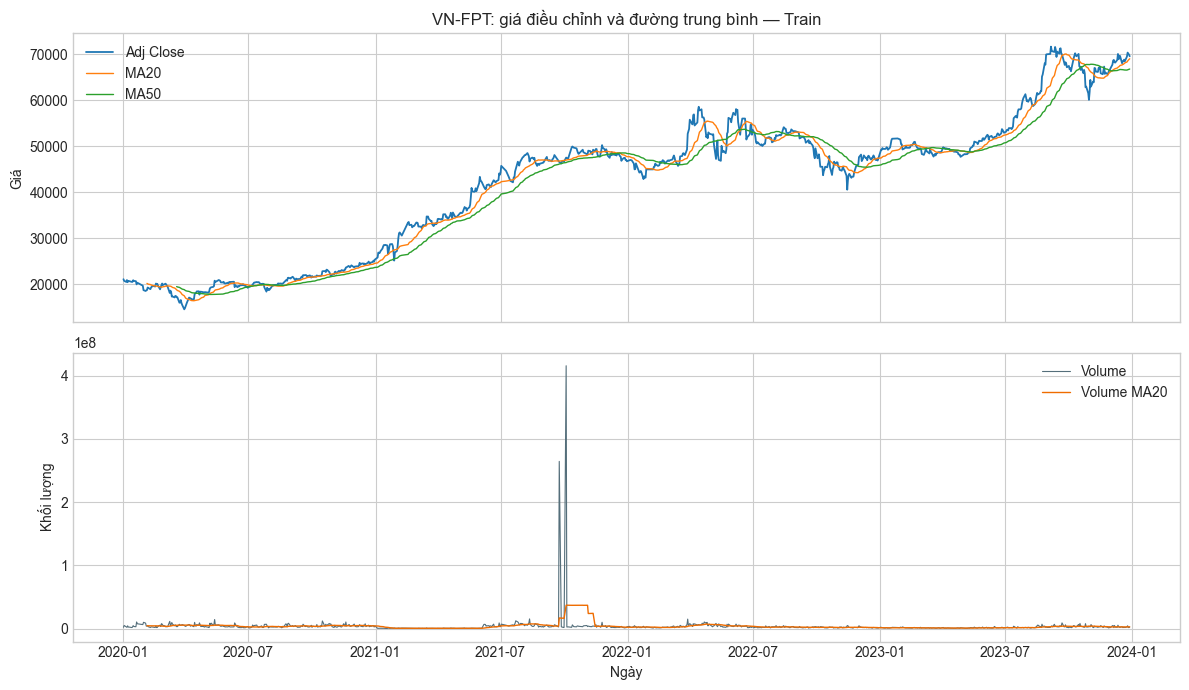

In [7]:
def add_features(frame):
    data = frame.copy()
    price = data["Adj Close"]

    data["Return_1D"] = price.pct_change(fill_method=None)
    data["Return_5D"] = price.pct_change(5, fill_method=None)
    data["Return_20D"] = price.pct_change(20, fill_method=None)
    data["Cumulative_Return"] = price / price.iloc[0] - 1

    data["MA20"] = price.rolling(20, min_periods=20).mean()
    data["MA50"] = price.rolling(50, min_periods=50).mean()
    data["Price_vs_MA20"] = price / data["MA20"] - 1
    data["Price_vs_MA50"] = price / data["MA50"] - 1
    data["Volatility_20_Ann"] = (
        data["Return_1D"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(252)
    )

    data["Volume_MA20"] = data["Volume"].rolling(20, min_periods=20).mean()
    data["RVOL"] = data["Volume"] / data["Volume_MA20"]
    data["Running_Max"] = price.cummax()
    data["Drawdown"] = price / data["Running_Max"] - 1
    data["Abs_Return"] = data["Return_1D"].abs()
    data["Year"] = data["Date"].dt.year
    return data

SELECTED = add_features(SELECTED_CLEAN)
TRAIN = SELECTED[SELECTED["Split"].eq("Train")].copy()

OVERVIEW = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng sạch toàn kỳ",
        "Số dòng Train",
        "Ngày đầu toàn kỳ",
        "Ngày cuối toàn kỳ",
        "Ngày đầu Train",
        "Ngày cuối Train",
    ],
    "Giá trị": [
        len(SELECTED),
        len(TRAIN),
        SELECTED["Date"].min(),
        SELECTED["Date"].max(),
        TRAIN["Date"].min(),
        TRAIN["Date"].max(),
    ],
})

display(OVERVIEW)
display(TRAIN.head())
display(TRAIN.tail())
display(TRAIN[["Adj Close", "Volume", "Return_1D", "Return_5D", "Return_20D"]].describe().T)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(TRAIN["Date"], TRAIN["Adj Close"], label="Adj Close", linewidth=1.3)
axes[0].plot(TRAIN["Date"], TRAIN["MA20"], label="MA20", linewidth=1)
axes[0].plot(TRAIN["Date"], TRAIN["MA50"], label="MA50", linewidth=1)
axes[0].set_title(f"{selected_market}-{selected_ticker}: giá điều chỉnh và đường trung bình — Train")
axes[0].set_ylabel("Giá")
axes[0].legend()

axes[1].plot(TRAIN["Date"], TRAIN["Volume"], color="#546E7A", linewidth=0.8, label="Volume")
axes[1].plot(TRAIN["Date"], TRAIN["Volume_MA20"], color="#EF6C00", linewidth=1, label="Volume MA20")
axes[1].set_ylabel("Khối lượng")
axes[1].set_xlabel("Ngày")
axes[1].legend()
plt.tight_layout()
plt.show()



Train có 960 quan sát, tương đương 59,33% dữ liệu sạch toàn kỳ. Các giá trị NaN ở đầu MA, volatility và RVOL xuất hiện do chưa đủ lookback, không phải lỗi dữ liệu.

## 4. Lợi nhuận, xu hướng và rủi ro

Phần này mô tả phân phối return, thay đổi theo năm, các phiên bất thường, rolling volatility và drawdown.

In [8]:
RETURN_STATS = []
for column in ["Return_1D", "Return_5D", "Return_20D"]:
    values = TRAIN[column].dropna()
    RETURN_STATS.append({
        "Biến": column,
        "N": len(values),
        "Mean": values.mean(),
        "Median": values.median(),
        "Std": values.std(ddof=1),
        "Q05": values.quantile(0.05),
        "Q95": values.quantile(0.95),
        "Min": values.min(),
        "Max": values.max(),
    })
RETURN_STATS = pd.DataFrame(RETURN_STATS)

annual_rows = []
for year, group in TRAIN.groupby("Year"):
    daily_return = group["Return_1D"].dropna()
    yearly_drawdown = group["Adj Close"] / group["Adj Close"].cummax() - 1
    annual_rows.append({
        "Năm": year,
        "Số phiên": len(group),
        "Return năm": group["Adj Close"].iloc[-1] / group["Adj Close"].iloc[0] - 1,
        "Return ngày TB": daily_return.mean(),
        "Volatility annualized": daily_return.std(ddof=1) * np.sqrt(252),
        "Max drawdown trong năm": yearly_drawdown.min(),
    })
ANNUAL_STATS = pd.DataFrame(annual_rows)
display(RETURN_STATS)
display(ANNUAL_STATS)

,Biến,N,Mean,Median,Std,Q05,Q95,Min,Max
0,Return_1D,959,0.0014,0.0010,0.0182,-0.0243,0.0328,-0.0698,0.0926
1,Return_5D,955,0.0072,0.0054,0.0402,-0.0578,0.0699,-0.1190,0.2372
2,Return_20D,940,0.0296,0.0295,0.0791,-0.0978,0.1676,-0.2668,0.2935


,Năm,Số phiên,Return năm,Return ngày TB,Volatility annualized,Max drawdown trong năm
0,2020,243,0.2024,0.0009,0.3029,-0.3106
1,2021,224,0.8106,0.0029,0.3044,-0.1254
2,2022,246,0.0074,0.0003,0.3354,-0.3078
3,2023,247,0.4131,0.0016,0.1993,-0.1616




Return ngày có mean 0,14% và median 0,10%, cho thấy phân phối chịu ảnh hưởng nhất định từ các phiên cực trị. Năm 2021 có return cao nhất 81,06%, còn năm 2022 thấp nhất với 0,74%.

In [9]:
LARGEST_MOVES = TRAIN.nlargest(10, "Abs_Return")[
    ["Date", "Adj Close", "Volume", "Return_1D", "RVOL"]
]

print("10 phiên có biến động tuyệt đối lớn nhất:")
display(LARGEST_MOVES)

10 phiên có biến động tuyệt đối lớn nhất:


,Date,Adj Close,Volume,Return_1D,RVOL
269,2021-02-17,"33,407.5117",658836,0.0926,1.0812
262,2021-01-29,"26,888.9668",674115,0.0700,1.2718
261,2021-01-28,"25,130.6777",1068796,-0.0698,1.5052
553,2022-05-17,"50,110.3203",3733687,0.0697,0.6205
521,2022-03-29,"52,723.8945",15009758,0.0693,4.0334
539,2022-04-25,"51,969.9766",8405997,-0.0693,1.1816
559,2022-05-25,"52,774.1602",6881898,0.0692,1.4776
679,2022-11-15,"40,568.5234",4737373,-0.0692,2.4714
51,2020-03-23,"15,971.0527",6822579,-0.0692,1.2457
41,2020-03-09,"18,093.3340",11428869,-0.0685,2.9123


### **10 phiên đột biến trên có thể lý giải như sau:**
**1. Cú sốc đại dịch COVID-19 (Tháng 03/2**020)
- 2020-03-09 (Giảm 6.85%): Phiên xuất hiện "ca bệnh thứ 17" tại Hà Nội sau chuỗi ngày không ghi nhận ca nhiễm mới trong nước, kết hợp với cú sốc giá dầu thế giới lao dốc (cuộc chiến giá dầu giữa Nga và Ả Rập Xê Út). Toàn bộ thị trường kích hoạt trạng thái bán tháo bán chéo.

- 2020-03-23 (Giảm 6.92%): Giai đoạn cao điểm hoảng loạn trước khi áp dụng các biện pháp giãn cách xã hội toàn quốc. Khối ngoại và margin call diện rộng khiến VN-Index lập đáy trung hạn, kéo theo các cổ phiếu trụ cột nhóm VN30 chạm giá sàn.

**2. Sự cố "nghẽn lệnh HOSE" và cú đạp trước Tết Tân Sửu (Đầu năm 2021)**
- 2021-01-28 (Giảm 6.98%): Phiên bán tháo lịch sử kỷ lục của thị trường (VN-Index giảm hơn 73 điểm). Thị trường chịu tác động kép từ làn sóng bùng phát dịch tại Hải Dương - Quảng Ninh cùng tình trạng căng cứng đòn bẩy ký quỹ (margin) tại hầu hết các công ty chứng khoán.

- 2021-01-29 (Tăng 7.00%): Ngay sau phiên hoảng loạn cực độ, dòng tiền bắt đáy nhập cuộc mạnh mẽ tạo nên phiên hồi phục kỹ thuật hình chữ V; FPT nhanh chóng dư mua trần.

- 2021-02-17 (Tăng 9.26% - tính cả mở Gap sau Tết): Phiên mở bát đầu tiên sau kỳ nghỉ Tết Âm lịch 2021. Khí thế dòng tiền dồi dào đầu năm kết hợp với sự kiện Tập đoàn FPT đề xuất Chính phủ triển khai phương án xử lý nghẽn hệ thống giao dịch của Sở HOSE trong 100 ngày.

**3. Hiệu ứng "FPT giải cứu HOSE" và sự kiện Tân Hoàng Minh (Tháng 03 - 04/2022)**
- 2022-03-29 (Tăng 6.93%, thanh khoản gấp 4 lần bình thường):
  - Đây là phiên bùng nổ thanh khoản kỷ lục của FPT (Relative Volume lên tới 4.03).
  - Thị trường đón nhận thông tin các tập đoàn công nghệ lớn mở rộng hợp tác toàn cầu và kỳ vọng mùa Đại hội đồng cổ đông (ĐHCĐ) 2022 với kế hoạch tăng trưởng mạnh mảng chuyển đổi số. Dòng tiền lớn chuyển dịch mạnh từ nhóm cổ phiếu đầu cơ bất động sản sang nhóm sản xuất - công nghệ cơ bản có định giá an toàn.

- 2022-04-25 (Giảm 6.93%): Đợt thanh lọc thị trường tài chính (xử lý sai phạm nhóm FLC, Tân Hoàng Minh) gây áp lực bán giải chấp chéo dây chuyền. Dù nội tại kinh doanh tốt, FPT vẫn bị bán để bù đắp thanh khoản cho danh mục margin của nhà đầu tư.

**4. Giai đoạn tạo đáy hoảng loạn và sóng hồi kỹ thuật (Tháng 05 & Tháng 11/2022)**
- 2022-05-17 (Tăng 6.97%) & 2022-05-25 (Tăng 6.92%): Những phiên "bùng nổ theo đà" khi VN-Index kiểm định mốc hỗ trợ cứng quanh 1.150 - 1.200 điểm sau đợt sụt giảm quý 2/2022. FPT thường là cổ phiếu blue-chip dẫn dắt chỉ số hồi phục đầu tiên.

- 2022-11-15 (Giảm 6.92%, Relative Volume 2.47): Phiên kiểm định đáy lịch sử 873 điểm của VN-Index do khủng hoảng thanh khoản trái phiếu doanh nghiệp và làn sóng giải chấp diện rộng tài khoản lãnh đạo nhiều tập đoàn bất động sản lớn. FPT chịu áp lực xả hàng mạnh ở vùng đáy tuyệt đối trước khi thị trường đảo chiều sang chu kỳ phục hồi từ ngày 16/11/2022.

*Nguồn tổng hợp: **Gemini***

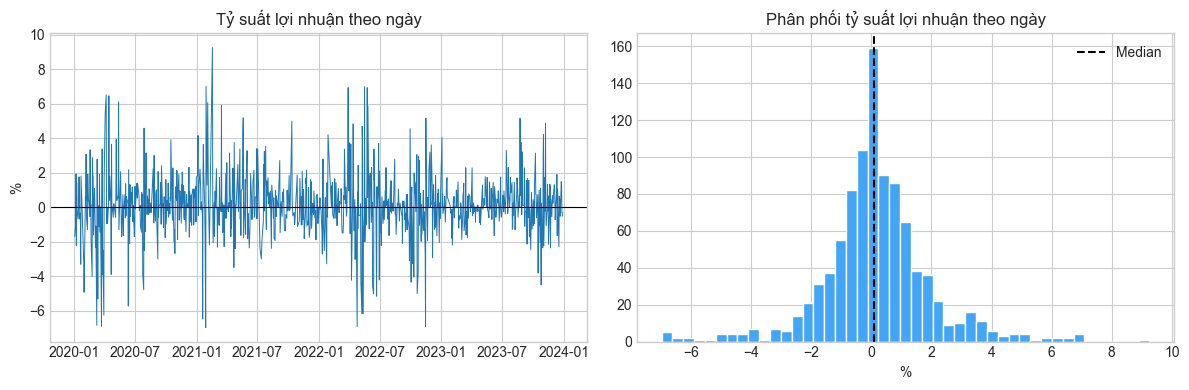

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(TRAIN["Date"], TRAIN["Return_1D"] * 100, linewidth=0.7)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Tỷ suất lợi nhuận theo ngày")
axes[0].set_ylabel("%")

daily = TRAIN["Return_1D"].dropna() * 100
axes[1].hist(daily, bins=45, color="#42A5F5", edgecolor="white")
axes[1].axvline(daily.median(), color="black", linestyle="--", label="Median")
axes[1].set_title("Phân phối tỷ suất lợi nhuận theo ngày")
axes[1].set_xlabel("%")
axes[1].legend()
plt.tight_layout()
plt.show()

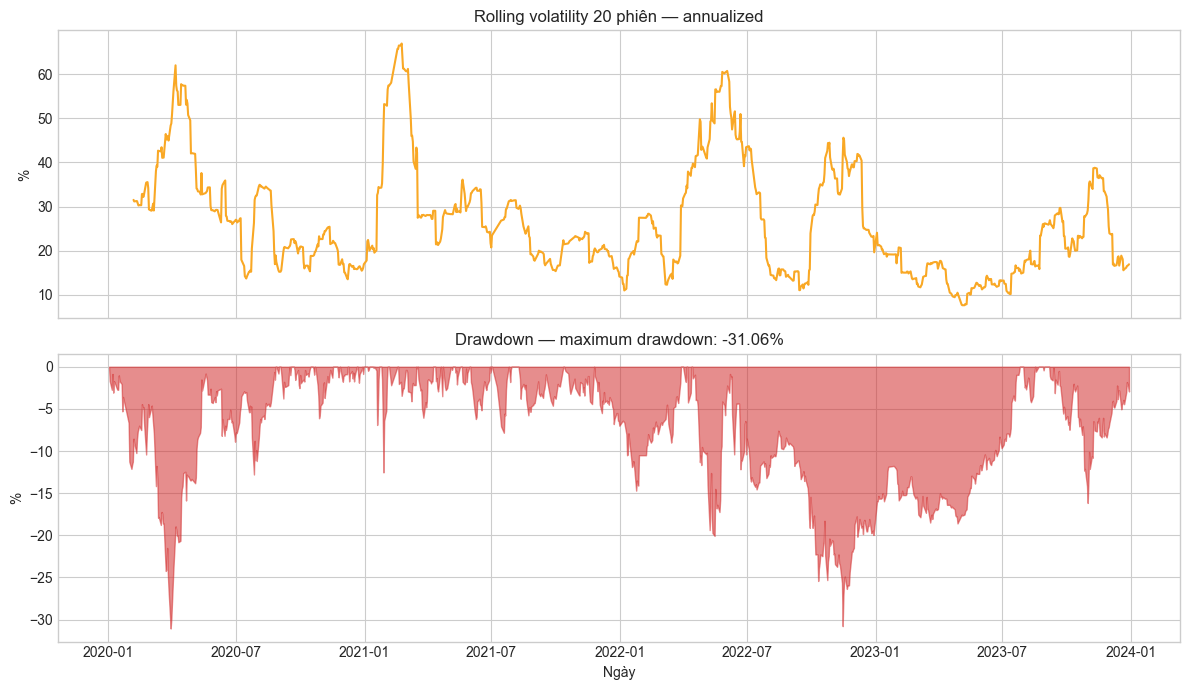

In [11]:
MAX_DRAWDOWN = TRAIN["Drawdown"].min()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(TRAIN["Date"], TRAIN["Volatility_20_Ann"] * 100, color="#F9A825")
axes[0].set_title("Rolling volatility 20 phiên — annualized")
axes[0].set_ylabel("%")

axes[1].fill_between(
    TRAIN["Date"],
    TRAIN["Drawdown"] * 100,
    0,
    color="#D32F2F",
    alpha=0.55,
)
axes[1].set_title(f"Drawdown — maximum drawdown: {MAX_DRAWDOWN:.2%}")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

## 5. Phân tích khối lượng

Ngoài kiểm tra `Volume = 0`, phần này xem relative volume và mối liên hệ mô tả giữa khối lượng bất thường với độ lớn của return.

In [12]:
volume_sample = TRAIN[["Abs_Return", "RVOL"]].dropna()
VOLUME_RETURN_CORRELATION = volume_sample["Abs_Return"].corr(volume_sample["RVOL"])

VOLUME_BY_YEAR = (
    TRAIN.groupby("Year", as_index=False)
    .agg(
        **{
            "Số phiên": ("Date", "size"),
            "Volume trung vị": ("Volume", "median"),
            "Relative Volume trung vị": ("RVOL", "median"),
        }
    )
)

print(f"Correlation giữa |return ngày| và Relative Volume: {VOLUME_RETURN_CORRELATION:.4f}")
display(VOLUME_BY_YEAR)

Correlation giữa |return ngày| và Relative Volume: 0.2190


,Year,Số phiên,Volume trung vị,Relative Volume trung vị
0,2020,243,"3,650,539.0000",0.8880
1,2021,224,"1,986,658.0000",0.8334
2,2022,246,"2,365,645.0000",0.9107
3,2023,247,"1,600,357.0000",0.9163




Correlation giữa |return| và RVOL bằng 0,219, cho thấy quan hệ tuyến tính ở mức yếu. RVOL trung vị là 0,89, nghĩa là một nửa số phiên có volume thấp hơn khoảng 0,89 lần MA20.

In [13]:
HIGH_VOLUME_DAYS = TRAIN.nlargest(10, "RVOL")[
    ["Date", "Volume", "RVOL", "Return_1D", "Abs_Return"]
]
print("10 phiên có Relative Volume cao nhất:")
display(HIGH_VOLUME_DAYS)

10 phiên có Relative Volume cao nhất:


,Date,Volume,RVOL,Return_1D,Abs_Return
406,2021-09-24,264449745,15.7115,-0.0043,0.0043
412,2021-10-04,415709889,11.2376,0.0183,0.0183
343,2021-06-07,6773125,8.1104,-0.0236,0.0236
344,2021-06-09,6526561,5.7269,-0.0121,0.0121
521,2022-03-29,15009758,4.0334,0.0693,0.0693
345,2021-06-10,4042303,3.0568,0.0024,0.0024
188,2020-10-16,12109153,3.0298,0.0391,0.0391
41,2020-03-09,11428869,2.9123,-0.0685,0.0685
870,2023-08-24,6945241,2.8609,0.0515,0.0515
346,2021-06-11,4306387,2.8503,0.0195,0.0195


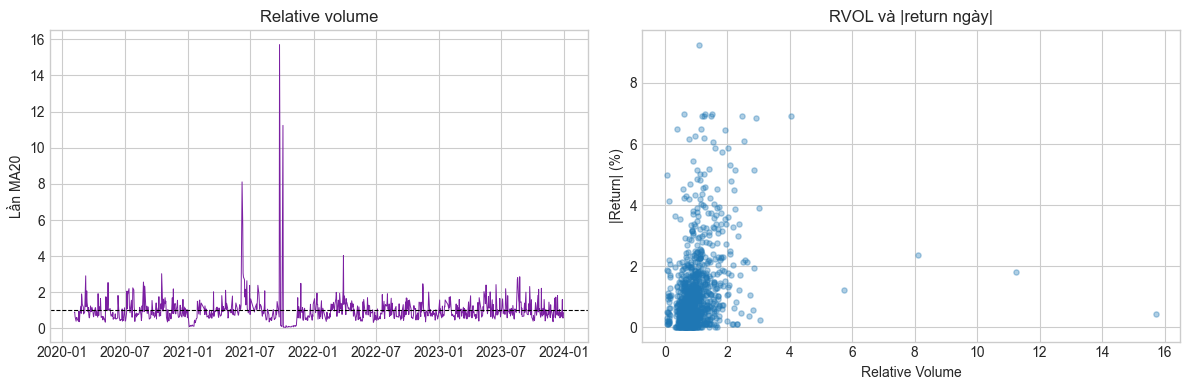

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(TRAIN["Date"], TRAIN["RVOL"], linewidth=0.7, color="#7B1FA2")
axes[0].axhline(1, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Relative volume")
axes[0].set_ylabel("Lần MA20")

axes[1].scatter(
    volume_sample["RVOL"],
    volume_sample["Abs_Return"] * 100,
    alpha=0.35,
    s=14,
)
axes[1].set_title("RVOL và |return ngày|")
axes[1].set_xlabel("Relative Volume")
axes[1].set_ylabel("|Return| (%)")
plt.tight_layout()
plt.show()

## 6. Phân tích chân trời dự báo

Một “phiên” được hiểu là một dòng giao dịch quan sát được sau làm sạch. Các khoảng trống ngày được báo riêng ở phần chất lượng dữ liệu thay vì dùng lịch thứ Hai–thứ Sáu để loại hàng loạt cửa sổ.

Target chỉ hợp lệ khi ngày bắt đầu và endpoint thuộc cùng Train/Validation/Test. Vì vậy target cuối Train không nhìn sang Validation.

,T,N,Mean return,Median return,Std,Q05,Q95,P(UP),P(DOWN),Mean return mỗi phiên
0,1,959,0.0014,0.0010,0.0182,-0.0243,0.0328,0.5036,0.4964,0.0014
1,5,955,0.0072,0.0054,0.0402,-0.0578,0.0699,0.5654,0.4346,0.0013
2,10,950,0.0144,0.0106,0.0580,-0.0800,0.1233,0.6042,0.3958,0.0013
3,20,940,0.0296,0.0295,0.0791,-0.0978,0.1676,0.6574,0.3426,0.0013
4,30,930,0.0449,0.0446,0.0961,-0.1098,0.2049,0.6753,0.3247,0.0013


,T,Năm,N,Mean return,P(UP)
0,1,2020,243,0.0010,0.5309
1,1,2021,224,0.0029,0.4821
2,1,2022,246,0.0004,0.5081
3,1,2023,246,0.0015,0.4919
4,5,2020,243,0.0061,0.6091
5,5,2021,224,0.0135,0.5804
6,5,2022,246,0.0020,0.4878
7,5,2023,242,0.0076,0.5868
8,10,2020,243,0.0138,0.6379
9,10,2021,224,0.0248,0.6295


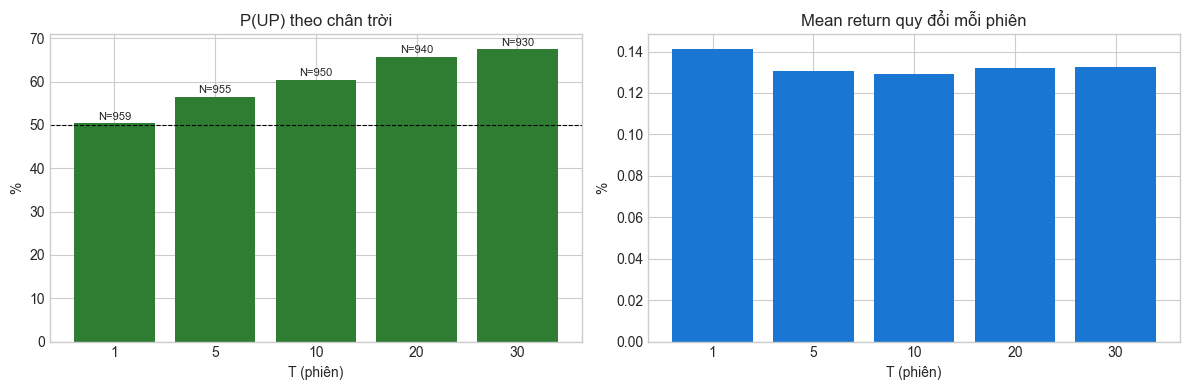

In [15]:
def add_horizon_targets(frame, horizons):
    data = frame.copy()
    for horizon in horizons:
        future_price = data["Adj Close"].shift(-horizon)
        future_date = data["Date"].shift(-horizon)
        same_split = data["Split"].eq(data["Split"].shift(-horizon))

        future_return = (future_price / data["Adj Close"] - 1).where(same_split)
        data[f"FutureReturn_{horizon}"] = future_return
        data[f"Target_{horizon}"] = np.where(
            future_return.notna(),
            future_return.gt(0).astype(float),
            np.nan,
        )
        data[f"EndpointDate_{horizon}"] = future_date.where(same_split)
    return data

SELECTED_WITH_TARGETS = add_horizon_targets(SELECTED, CONFIG["HORIZONS"])
TRAIN_WITH_TARGETS = SELECTED_WITH_TARGETS[
    SELECTED_WITH_TARGETS["Split"].eq("Train")
].copy()

horizon_rows = []
stability_rows = []
for horizon in CONFIG["HORIZONS"]:
    column = f"FutureReturn_{horizon}"
    values = TRAIN_WITH_TARGETS[column].dropna()
    per_session = (1 + values).pow(1 / horizon) - 1

    horizon_rows.append({
        "T": horizon,
        "N": len(values),
        "Mean return": values.mean(),
        "Median return": values.median(),
        "Std": values.std(ddof=1),
        "Q05": values.quantile(0.05),
        "Q95": values.quantile(0.95),
        "P(UP)": values.gt(0).mean(),
        "P(DOWN)": values.le(0).mean(),
        "Mean return mỗi phiên": per_session.mean(),
    })

    valid = TRAIN_WITH_TARGETS.loc[values.index, ["Date"]].copy()
    valid["Return"] = values
    valid["Năm"] = valid["Date"].dt.year
    for year, group in valid.groupby("Năm"):
        stability_rows.append({
            "T": horizon,
            "Năm": year,
            "N": len(group),
            "Mean return": group["Return"].mean(),
            "P(UP)": group["Return"].gt(0).mean(),
        })

HORIZON_SUMMARY = pd.DataFrame(horizon_rows)
HORIZON_BY_YEAR = pd.DataFrame(stability_rows)

display(HORIZON_SUMMARY)
display(HORIZON_BY_YEAR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(HORIZON_SUMMARY["T"].astype(str), HORIZON_SUMMARY["P(UP)"] * 100, color="#2E7D32")
axes[0].axhline(50, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("P(UP) theo chân trời")
axes[0].set_xlabel("T (phiên)")
axes[0].set_ylabel("%")
for index, row in HORIZON_SUMMARY.iterrows():
    axes[0].text(index, row["P(UP)"] * 100 + 0.8, f"N={int(row['N'])}", ha="center", fontsize=8)

axes[1].bar(
    HORIZON_SUMMARY["T"].astype(str),
    HORIZON_SUMMARY["Mean return mỗi phiên"] * 100,
    color="#1976D2",
)
axes[1].set_title("Mean return quy đổi mỗi phiên")
axes[1].set_xlabel("T (phiên)")
axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

#### Nhận xét

Đối với FPT, T=30 có P(UP) mô tả cao nhất ở mức 67,53%. P(UP) và return thô thường tăng theo T nên cần đọc cùng return mỗi phiên, độ phân tán và mức ổn định theo năm; kết quả một mã chỉ dùng để minh họa, không dùng để chọn common T.


## 7. Tổng hợp toàn bộ mẫu cổ phiếu

Bảng dưới đây mô tả **mẫu VN30** và **mẫu 20 mã Nasdaq**, không đại diện cho toàn bộ hai thị trường. Các mã được cho trọng số bằng nhau trong bảng so sánh nhóm.

,Mẫu,Số mã có Train,Mean return ngày — TB công ty,Volatility — trung vị công ty,Maximum drawdown — trung vị,P(UP) T=20 — TB công ty
0,20 mã Nasdaq,20,0.0011,0.3756,-0.4645,0.5846
1,VN30,29,0.0008,0.3678,-0.5437,0.5422


,Thị trường,Mẫu,Mã,Số dòng Train,Ngày đầu Train,Ngày cuối Train,Mean return ngày,Volatility annualized,Maximum drawdown,P(UP)_1,N_1,P(UP)_5,N_5,P(UP)_10,N_10,P(UP)_20,N_20,P(UP)_30,N_30
0,US,20 mã Nasdaq,AAPL,1006,2020-01-02,2023-12-29,0.0012,0.3357,-0.3143,0.5254,1005,0.5744,1001,0.6124,996,0.6308,986,0.6137,976
1,US,20 mã Nasdaq,ADBE,1006,2020-01-02,2023-12-29,0.0009,0.3942,-0.6002,0.5313,1005,0.5574,1001,0.6094,996,0.5852,986,0.5789,976
2,US,20 mã Nasdaq,AMD,1006,2020-01-02,2023-12-29,0.0017,0.5355,-0.6545,0.4985,1005,0.5315,1001,0.5321,996,0.5243,986,0.5195,976
3,US,20 mã Nasdaq,AMGN,1006,2020-01-02,2023-12-29,0.0004,0.2632,-0.2486,0.4905,1005,0.5225,1001,0.5060,996,0.5030,986,0.5318,976
4,US,20 mã Nasdaq,AMZN,1006,2020-01-02,2023-12-29,0.0007,0.3769,-0.5615,0.5184,1005,0.5345,1001,0.5592,996,0.5822,986,0.5645,976
5,US,20 mã Nasdaq,AVGO,1006,2020-01-02,2023-12-29,0.0017,0.3830,-0.4830,0.5303,1005,0.5934,1001,0.6386,996,0.6856,986,0.6916,976
6,US,20 mã Nasdaq,COST,1006,2020-01-02,2023-12-29,0.0010,0.2531,-0.3140,0.5463,1005,0.5904,1001,0.6305,996,0.6613,986,0.6629,976
7,US,20 mã Nasdaq,CSCO,1006,2020-01-02,2023-12-29,0.0003,0.2915,-0.3668,0.5075,1005,0.5644,1001,0.5673,996,0.5730,986,0.5871,976
8,US,20 mã Nasdaq,GOOG,1006,2020-01-02,2023-12-29,0.0009,0.3346,-0.4460,0.5393,1005,0.5684,1001,0.5843,996,0.6085,986,0.6045,976
9,US,20 mã Nasdaq,GOOGL,1006,2020-01-02,2023-12-29,0.0009,0.3353,-0.4432,0.5343,1005,0.5604,1001,0.5843,996,0.5984,986,0.6025,976


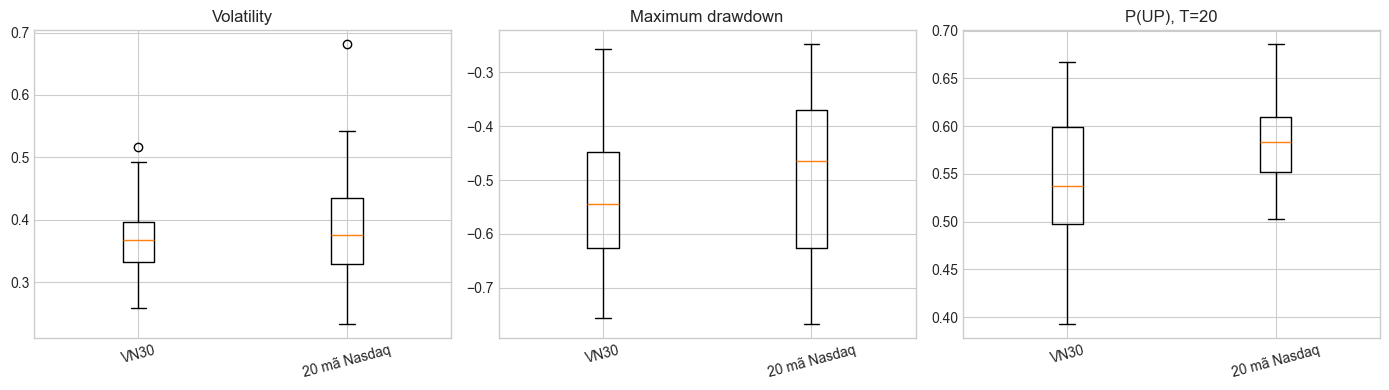

In [16]:
stock_rows = []
quality_rows = []
failures = []
panel_frames = []

for item in FILES.itertuples(index=False):
    try:
        _, clean, quality = load_stock(item.path, item.market, item.ticker)
        quality_rows.append(quality)

        featured = add_features(clean)
        targeted = add_horizon_targets(featured, CONFIG["HORIZONS"])
        targeted.insert(0, "Mã", item.ticker)
        targeted.insert(0, "Thị trường", item.market)
        panel_frames.append(targeted)
        train = targeted[targeted["Split"].eq("Train")].copy()
        daily = train["Return_1D"].dropna()

        row = {
            "Thị trường": item.market,
            "Mẫu": "VN30" if item.market == "VN" else "20 mã Nasdaq",
            "Mã": item.ticker,
            "Số dòng Train": len(train),
            "Ngày đầu Train": train["Date"].min() if not train.empty else pd.NaT,
            "Ngày cuối Train": train["Date"].max() if not train.empty else pd.NaT,
            "Mean return ngày": daily.mean() if len(daily) else np.nan,
            "Volatility annualized": daily.std(ddof=1) * np.sqrt(252) if len(daily) > 1 else np.nan,
            "Maximum drawdown": train["Drawdown"].min() if not train.empty else np.nan,
        }
        for horizon in CONFIG["HORIZONS"]:
            target = train[f"Target_{horizon}"].dropna()
            row[f"P(UP)_{horizon}"] = target.mean() if len(target) else np.nan
            row[f"N_{horizon}"] = len(target)
        stock_rows.append(row)
    except Exception as exc:
        failures.append({
            "Thị trường": item.market,
            "Mã": item.ticker,
            "Lỗi": f"{type(exc).__name__}: {exc}",
        })

PANEL = pd.concat(panel_frames, ignore_index=True) if panel_frames else pd.DataFrame()
ALL_STOCKS_SUMMARY = pd.DataFrame(stock_rows)
ALL_DATA_QUALITY = pd.DataFrame(quality_rows)
PROCESSING_FAILURES = pd.DataFrame(failures)

MARKET_COMPARISON = (
    ALL_STOCKS_SUMMARY.groupby("Mẫu", as_index=False)
    .agg(
        **{
            "Số mã có Train": ("Số dòng Train", lambda x: int(x.gt(0).sum())),
            "Mean return ngày — TB công ty": ("Mean return ngày", "mean"),
            "Volatility — trung vị công ty": ("Volatility annualized", "median"),
            "Maximum drawdown — trung vị": ("Maximum drawdown", "median"),
            "P(UP) T=20 — TB công ty": ("P(UP)_20", "mean"),
        }
    )
)

display(MARKET_COMPARISON)
display(ALL_STOCKS_SUMMARY)
if not PROCESSING_FAILURES.empty:
    print("Các file xử lý thất bại:")
    display(PROCESSING_FAILURES)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [
    ("Volatility annualized", "Volatility"),
    ("Maximum drawdown", "Maximum drawdown"),
    ("P(UP)_20", "P(UP), T=20"),
]
samples = ["VN30", "20 mã Nasdaq"]
for axis, (column, title) in zip(axes, metrics):
    values = [
        ALL_STOCKS_SUMMARY.loc[ALL_STOCKS_SUMMARY["Mẫu"].eq(sample), column].dropna()
        for sample in samples
    ]
    axis.boxplot(values, tick_labels=samples)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()



Mẫu 20 mã Nasdaq có volatility trung vị 37,56% và P(UP) tại T=20 là 58,46%, so với 36,78% và 54,22% của VN30. VPL không có dữ liệu Train nên không tham gia các thống kê có target.

## 8. EDA panel cho các chân trời T

Các kiểm tra dưới đây chỉ sử dụng dữ liệu **Train** của toàn bộ mã. Mỗi ngày trong từng thị trường được xem là một nhóm ranking; các công ty trong ngày đó được xếp theo `FutureReturn_T`.

Phần này lần lượt xem:

1. thống kê horizon, coverage và label balance;
2. số ngày ranking và số công ty khả dụng mỗi ngày;
3. độ phân tách cross-sectional của future return;
4. độ dài thực tế của T theo ngày lịch;
5. feature–target correlation giữa các công ty trong cùng ngày;
6. mức trùng lặp ranking giữa các T;
7. độ ổn định theo năm và bảng tổng hợp để shortlist T.

Mục tiêu là hiểu chất lượng target cho predictive ranking, không huấn luyện hay đánh giá mô hình.


,Thị trường,T,Số mã,Số dòng Train,N target,Coverage target,Mean return,Median return,Std,Q05,Q95,P(UP),Mean return mỗi phiên
0,US,1,20,20120,20100,0.9990,0.0011,0.0008,0.0254,-0.0368,0.0393,0.5232,0.0011
1,US,5,20,20120,20020,0.9950,0.0052,0.0050,0.0542,-0.0772,0.0892,0.5521,0.0008
2,US,10,20,20120,19920,0.9901,0.0103,0.0103,0.0768,-0.1072,0.1279,0.5709,0.0008
3,US,20,20,20120,19720,0.9801,0.0202,0.0179,0.1123,-0.1447,0.1921,0.5846,0.0007
4,US,30,20,20120,19520,0.9702,0.0296,0.0249,0.1365,-0.1748,0.2472,0.5918,0.0007
5,VN,1,29,26719,26690,0.9989,0.0008,0.0000,0.0237,-0.0382,0.0405,0.4772,0.0008
6,VN,5,29,26719,26574,0.9946,0.0042,0.0026,0.0556,-0.0833,0.0925,0.5182,0.0006
7,VN,10,29,26719,26429,0.9891,0.0083,0.0056,0.0797,-0.1176,0.1394,0.5318,0.0005
8,VN,20,29,26719,26139,0.9783,0.0168,0.0094,0.1153,-0.1591,0.2050,0.5413,0.0005
9,VN,30,29,26719,25849,0.9674,0.0254,0.0157,0.1457,-0.1995,0.2655,0.5554,0.0005


,Thị trường,T,Năm,Số mã,N target,Mean return,P(UP)
0,US,1,2020,20,5060,0.0020,0.5405
1,US,1,2021,20,5040,0.0015,0.5391
2,US,1,2022,20,5020,-0.0015,0.4719
3,US,1,2023,20,4980,0.0022,0.5412
4,US,5,2020,20,5060,0.0099,0.5923
5,US,5,2021,20,5040,0.0065,0.5688
6,US,5,2022,20,5020,-0.0064,0.4584
7,US,5,2023,20,4900,0.0110,0.5896
8,US,10,2020,20,5060,0.0195,0.6279
9,US,10,2021,20,5040,0.0124,0.5952


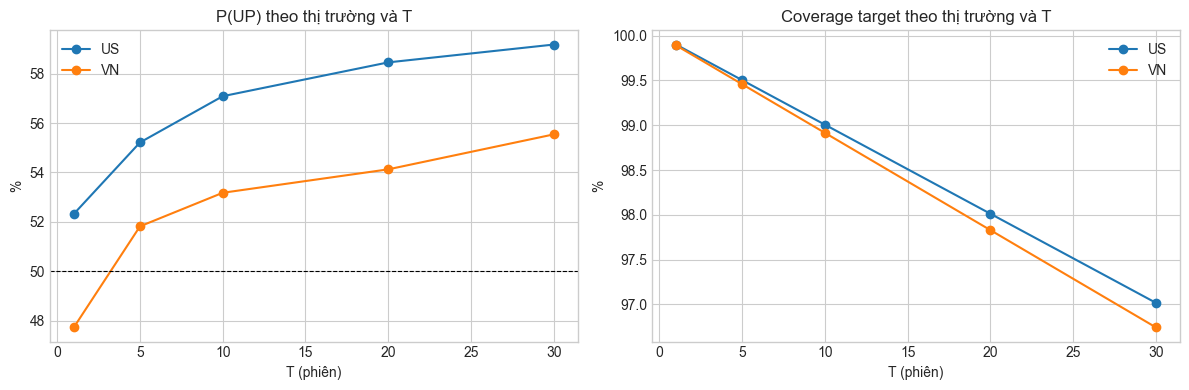

In [17]:
PANEL_TRAIN = PANEL[PANEL["Split"].eq("Train")].copy()

market_horizon_rows = []
market_horizon_year_rows = []

for market, market_data in PANEL_TRAIN.groupby("Thị trường"):
    for horizon in CONFIG["HORIZONS"]:
        column = f"FutureReturn_{horizon}"
        values = market_data[column].dropna()
        per_session = (1 + values).pow(1 / horizon) - 1

        market_horizon_rows.append({
            "Thị trường": market,
            "T": horizon,
            "Số mã": market_data.loc[values.index, "Mã"].nunique(),
            "Số dòng Train": len(market_data),
            "N target": len(values),
            "Coverage target": len(values) / len(market_data) if len(market_data) else np.nan,
            "Mean return": values.mean(),
            "Median return": values.median(),
            "Std": values.std(ddof=1),
            "Q05": values.quantile(0.05),
            "Q95": values.quantile(0.95),
            "P(UP)": values.gt(0).mean(),
            "Mean return mỗi phiên": per_session.mean(),
        })

        valid = market_data.loc[values.index, ["Date", "Mã"]].copy()
        valid["Future return"] = values
        valid["Năm"] = valid["Date"].dt.year
        for year, year_data in valid.groupby("Năm"):
            market_horizon_year_rows.append({
                "Thị trường": market,
                "T": horizon,
                "Năm": year,
                "Số mã": year_data["Mã"].nunique(),
                "N target": len(year_data),
                "Mean return": year_data["Future return"].mean(),
                "P(UP)": year_data["Future return"].gt(0).mean(),
            })

MARKET_HORIZON_SUMMARY = pd.DataFrame(market_horizon_rows)
MARKET_HORIZON_BY_YEAR = pd.DataFrame(market_horizon_year_rows)

display(MARKET_HORIZON_SUMMARY)
display(MARKET_HORIZON_BY_YEAR)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for market, group in MARKET_HORIZON_SUMMARY.groupby("Thị trường"):
    axes[0].plot(group["T"], group["P(UP)"] * 100, marker="o", label=market)
    axes[1].plot(group["T"], group["Coverage target"] * 100, marker="o", label=market)

axes[0].axhline(50, color="black", linestyle="--", linewidth=0.8)
axes[0].set(title="P(UP) theo thị trường và T", xlabel="T (phiên)", ylabel="%")
axes[1].set(title="Coverage target theo thị trường và T", xlabel="T (phiên)", ylabel="%")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

Coverage target thấp nhất vẫn đạt 97,02% ở US và 96,74% ở VN. P(UP) mô tả cao nhất của cả hai thị trường cùng xuất hiện tại T=30, lần lượt là 59,18% và 55,54%.

In [18]:
EDA_FEATURES = [
    "Return_1D",
    "Return_5D",
    "Return_20D",
    "Price_vs_MA20",
    "Price_vs_MA50",
    "Volatility_20_Ann",
    "RVOL",
    "Drawdown",
]

coverage_rows = []
for item in FILES.itertuples(index=False):
    stock = PANEL_TRAIN[
        PANEL_TRAIN["Thị trường"].eq(item.market)
        & PANEL_TRAIN["Mã"].eq(item.ticker)
    ]
    complete_features = (
        stock[EDA_FEATURES].notna().all(axis=1)
        if not stock.empty
        else pd.Series(dtype=bool)
    )

    row = {
        "Thị trường": item.market,
        "Mã": item.ticker,
        "Số dòng Train": len(stock),
        "Dòng đủ feature": int(complete_features.sum()) if len(complete_features) else 0,
        "Coverage feature": complete_features.mean() if len(complete_features) else np.nan,
    }
    for horizon in CONFIG["HORIZONS"]:
        valid_target = stock[f"FutureReturn_{horizon}"].notna() if not stock.empty else pd.Series(dtype=bool)
        usable = complete_features & valid_target if len(stock) else pd.Series(dtype=bool)
        row[f"Dòng dùng được T={horizon}"] = int(usable.sum()) if len(usable) else 0
        row[f"Coverage T={horizon}"] = usable.mean() if len(usable) else np.nan
    coverage_rows.append(row)

FEATURE_COVERAGE = pd.DataFrame(coverage_rows)

market_coverage_rows = []
for market, group in PANEL_TRAIN.groupby("Thị trường"):
    complete_features = group[EDA_FEATURES].notna().all(axis=1)
    for horizon in CONFIG["HORIZONS"]:
        usable = complete_features & group[f"FutureReturn_{horizon}"].notna()
        market_coverage_rows.append({
            "Thị trường": market,
            "T": horizon,
            "Số dòng Train": len(group),
            "Dòng đủ feature": int(complete_features.sum()),
            "Dòng đủ feature và target": int(usable.sum()),
            "Coverage sử dụng": usable.mean(),
        })

FEATURE_COVERAGE_BY_MARKET = pd.DataFrame(market_coverage_rows)

display(FEATURE_COVERAGE)
display(FEATURE_COVERAGE_BY_MARKET)

,Thị trường,Mã,Số dòng Train,Dòng đủ feature,Coverage feature,Dòng dùng được T=1,Coverage T=1,Dòng dùng được T=5,Coverage T=5,Dòng dùng được T=10,Coverage T=10,Dòng dùng được T=20,Coverage T=20,Dòng dùng được T=30,Coverage T=30
0,US,AAPL,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
1,US,ADBE,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
2,US,AMD,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
3,US,AMGN,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
4,US,AMZN,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
5,US,AVGO,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
6,US,COST,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
7,US,CSCO,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
8,US,GOOG,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215
9,US,GOOGL,1006,957,0.9513,956,0.9503,952,0.9463,947,0.9414,937,0.9314,927,0.9215


,Thị trường,T,Số dòng Train,Dòng đủ feature,Dòng đủ feature và target,Coverage sử dụng
0,US,1,20120,19140,19120,0.9503
1,US,5,20120,19140,19040,0.9463
2,US,10,20120,19140,18940,0.9414
3,US,20,20120,19140,18740,0.9314
4,US,30,20120,19140,18540,0.9215
5,VN,1,26719,25298,25269,0.9457
6,VN,5,26719,25298,25153,0.9414
7,VN,10,26719,25298,25008,0.9360
8,VN,20,26719,25298,24718,0.9251
9,VN,30,26719,25298,24428,0.9143




Coverage đủ feature và target của US giảm từ 95,03% tại T=1 xuống 92,15% tại T=30. Tại VN, tỷ lệ tương ứng giảm từ 94,57% xuống 91,43%, chủ yếu do lookback và phần cuối chuỗi không còn đủ endpoint.

In [19]:
label_rows = []
overlap_rows = []

for (market, ticker), stock in PANEL_TRAIN.groupby(["Thị trường", "Mã"]):
    for horizon in CONFIG["HORIZONS"]:
        targets = stock[f"Target_{horizon}"].dropna()
        returns = stock[f"FutureReturn_{horizon}"].dropna()

        label_rows.append({
            "Thị trường": market,
            "Mã": ticker,
            "T": horizon,
            "N": len(targets),
            "P(UP)": targets.mean() if len(targets) else np.nan,
            "P(DOWN)": 1 - targets.mean() if len(targets) else np.nan,
        })

        overlap_rows.append({
            "Thị trường": market,
            "Mã": ticker,
            "T": horizon,
            "N target": len(returns),
            "Số mẫu không chồng lấn xấp xỉ": int(np.ceil(len(returns) / horizon)) if len(returns) else 0,
            "Lag-1 autocorrelation": returns.autocorr(lag=1) if len(returns) > 2 else np.nan,
        })

LABEL_BALANCE = pd.DataFrame(label_rows)
LABEL_BALANCE_SUMMARY = (
    LABEL_BALANCE.groupby(["Thị trường", "T"], as_index=False)
    .agg(
        **{
            "Số mã": ("P(UP)", lambda values: int(values.notna().sum())),
            "Tổng nhãn": ("N", "sum"),
            "P(UP) trung bình": ("P(UP)", "mean"),
            "P(UP) trung vị": ("P(UP)", "median"),
            "P(UP) min": ("P(UP)", "min"),
            "P(UP) max": ("P(UP)", "max"),
        }
    )
)

OVERLAP_BY_STOCK = pd.DataFrame(overlap_rows)
OVERLAP_SUMMARY = (
    OVERLAP_BY_STOCK.groupby(["Thị trường", "T"], as_index=False)
    .agg(
        **{
            "N target": ("N target", "sum"),
            "Số mẫu không chồng lấn xấp xỉ": ("Số mẫu không chồng lấn xấp xỉ", "sum"),
            "Lag-1 autocorrelation trung vị": ("Lag-1 autocorrelation", "median"),
        }
    )
)
OVERLAP_SUMMARY["Tỷ lệ mẫu không chồng lấn xấp xỉ"] = (
    OVERLAP_SUMMARY["Số mẫu không chồng lấn xấp xỉ"] / OVERLAP_SUMMARY["N target"]
)

display(LABEL_BALANCE_SUMMARY)
display(LABEL_BALANCE)
display(OVERLAP_SUMMARY)

,Thị trường,T,Số mã,Tổng nhãn,P(UP) trung bình,P(UP) trung vị,P(UP) min,P(UP) max
0,US,1,20,20100,0.5232,0.5259,0.4905,0.5512
1,US,5,20,20020,0.5521,0.5465,0.5085,0.5934
2,US,10,20,19920,0.5709,0.5733,0.5030,0.6386
3,US,20,20,19720,0.5846,0.5837,0.5030,0.6856
4,US,30,20,19520,0.5918,0.5948,0.5000,0.6916
5,VN,1,29,26690,0.4772,0.4863,0.4196,0.5159
6,VN,5,29,26574,0.5183,0.5253,0.4209,0.5893
7,VN,10,29,26429,0.5324,0.5479,0.4179,0.6320
8,VN,20,29,26139,0.5422,0.5374,0.3926,0.6671
9,VN,30,29,25849,0.5559,0.5673,0.3688,0.6792


,Thị trường,Mã,T,N,P(UP),P(DOWN)
0,US,AAPL,1,1005,0.5254,0.4746
1,US,AAPL,5,1001,0.5744,0.4256
2,US,AAPL,10,996,0.6124,0.3876
3,US,AAPL,20,986,0.6308,0.3692
4,US,AAPL,30,976,0.6137,0.3863
...,...,...,...,...,...,...
240,VN,VRE,1,960,0.4698,0.5302
241,VN,VRE,5,956,0.4780,0.5220
242,VN,VRE,10,951,0.4869,0.5131
243,VN,VRE,20,941,0.4538,0.5462


,Thị trường,T,N target,Số mẫu không chồng lấn xấp xỉ,Lag-1 autocorrelation trung vị,Tỷ lệ mẫu không chồng lấn xấp xỉ
0,US,1,20100,20100,-0.1205,1.0000
1,US,5,20020,4020,0.7729,0.2008
2,US,10,19920,2000,0.8703,0.1004
3,US,20,19720,1000,0.9383,0.0507
4,US,30,19520,660,0.9584,0.0338
5,VN,1,26690,26690,0.0486,1.0000
6,VN,5,26574,5324,0.8141,0.2003
7,VN,10,26429,2652,0.9094,0.1003
8,VN,20,26139,1315,0.9510,0.0503
9,VN,30,25849,871,0.9678,0.0337


#### Nhận xét

P(UP) trung bình nằm trong khoảng 52,32–59,18% ở US và 47,72–55,59% ở VN. Với T=30, tỷ lệ mẫu không chồng lấn chỉ khoảng 3,4% ở cả hai thị trường; P(UP) được giữ như thống kê phụ, không phải tiêu chí trực tiếp để chọn T cho ranking.


### 8.1. Đơn vị ranking, độ phủ universe và độ phân tách target

Notebook sử dụng universe động theo dữ liệu có sẵn trong từng ngày. `P90-P10` đo khoảng cách giữa nhóm return cao và thấp; tỷ lệ giữ lại Top 20% so sánh nhóm dẫn đầu giữa hai ngày ranking liên tiếp và thường tăng cơ học khi target dài hơn do các cửa sổ chồng lấn.


,Thị trường,Số mã trong danh sách,Số mã có Train,Số ngày Train,Số mã/ngày trung vị,Số mã/ngày nhỏ nhất,Số mã đủ feature/ngày trung vị,Số mã đủ feature/ngày nhỏ nhất
0,US,20,20,1006,20.0000,20,20.0000,0
1,VN,30,29,988,29.0000,1,29.0000,0


,Thị trường,T,Số ngày ranking,Số mã/ngày trung vị,Số mã/ngày nhỏ nhất,Target std trung vị,P90-P10 trung vị,Số ngày lịch trung vị,Số ngày lịch Q25,Số ngày lịch Q75,Tỷ lệ giữ lại Top 20% trung vị,Số block thời gian xấp xỉ
0,US,1,1005,20.0000,20,0.0147,0.0296,1.0000,1.0000,1.0000,0.2500,1005
1,US,5,1001,20.0000,20,0.0346,0.0713,7.0000,7.0000,7.0000,0.7500,201
2,US,10,996,20.0000,20,0.0505,0.1059,14.0000,14.0000,15.0000,0.7500,100
3,US,20,986,20.0000,20,0.0730,0.1547,29.0000,28.0000,29.0000,0.7500,50
4,US,30,976,20.0000,20,0.0937,0.1974,43.0000,43.0000,44.0000,0.7500,33
5,VN,1,965,29.0000,5,0.0160,0.0339,1.0000,1.0000,1.0000,0.1667,965
6,VN,5,961,29.0000,5,0.0365,0.0794,7.0000,7.0000,7.0000,0.6667,193
7,VN,10,956,29.0000,5,0.0525,0.1153,14.0000,14.0000,15.0000,0.8000,96
8,VN,20,946,29.0000,5,0.0786,0.1723,29.0000,28.0000,32.0000,0.8333,48
9,VN,30,936,29.0000,5,0.0999,0.2185,44.0000,42.0000,48.0000,0.8333,32


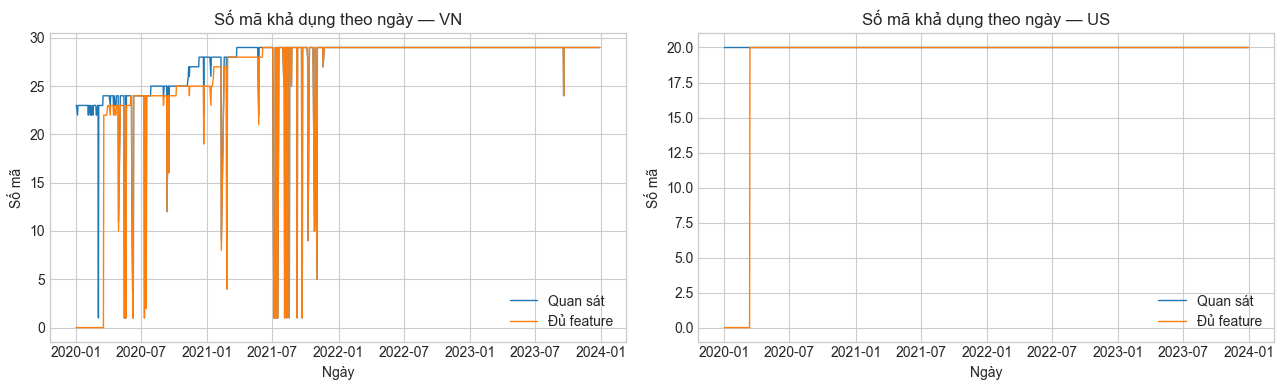

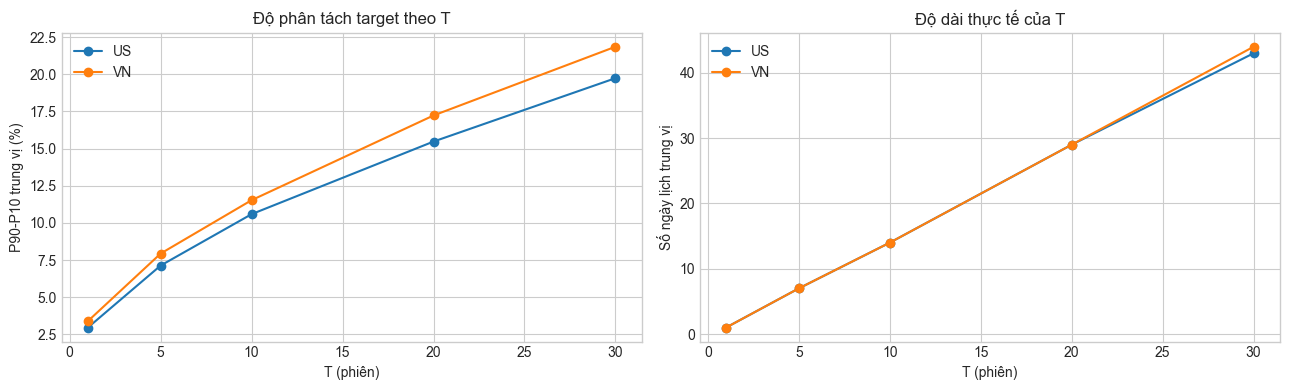

In [20]:
universe_rows = []
for (market, date), day in PANEL_TRAIN.groupby(["Thị trường", "Date"]):
    complete_features = day[EDA_FEATURES].notna().all(axis=1)
    row = {
        "Thị trường": market,
        "Date": date,
        "Số mã quan sát": day["Mã"].nunique(),
        "Số mã đủ feature": day.loc[complete_features, "Mã"].nunique(),
    }
    for horizon in CONFIG["HORIZONS"]:
        usable = complete_features & day[f"FutureReturn_{horizon}"].notna()
        row[f"Số mã dùng được T={horizon}"] = day.loc[usable, "Mã"].nunique()
    universe_rows.append(row)

UNIVERSE_BY_DATE = pd.DataFrame(universe_rows)

universe_summary_rows = []
for market, group in UNIVERSE_BY_DATE.groupby("Thị trường"):
    universe_summary_rows.append({
        "Thị trường": market,
        "Số mã trong danh sách": int(FILES["market"].eq(market).sum()),
        "Số mã có Train": int(PANEL_TRAIN.loc[PANEL_TRAIN["Thị trường"].eq(market), "Mã"].nunique()),
        "Số ngày Train": group["Date"].nunique(),
        "Số mã/ngày trung vị": group["Số mã quan sát"].median(),
        "Số mã/ngày nhỏ nhất": group["Số mã quan sát"].min(),
        "Số mã đủ feature/ngày trung vị": group["Số mã đủ feature"].median(),
        "Số mã đủ feature/ngày nhỏ nhất": group["Số mã đủ feature"].min(),
    })
UNIVERSE_SUMMARY = pd.DataFrame(universe_summary_rows)

ranking_rows = []
for (market, date), day in PANEL_TRAIN.groupby(["Thị trường", "Date"]):
    for horizon in CONFIG["HORIZONS"]:
        target = f"FutureReturn_{horizon}"
        endpoint = f"EndpointDate_{horizon}"
        valid = day[["Mã", target, endpoint]].dropna()
        if len(valid) < 5:
            continue

        q10 = valid[target].quantile(0.10)
        q90 = valid[target].quantile(0.90)
        calendar_days = (valid[endpoint] - date).dt.days
        ranking_rows.append({
            "Thị trường": market,
            "Date": date,
            "Năm": date.year,
            "T": horizon,
            "Số mã": valid["Mã"].nunique(),
            "Target std": valid[target].std(ddof=1),
            "P10": q10,
            "P90": q90,
            "P90-P10": q90 - q10,
            "Số ngày lịch": calendar_days.median(),
        })

RANKING_DAILY_PROFILE = pd.DataFrame(ranking_rows)

top_group_rows = []
for market, market_data in PANEL_TRAIN.groupby("Thị trường"):
    for horizon in CONFIG["HORIZONS"]:
        previous_top = None
        target = f"FutureReturn_{horizon}"
        for date, day in market_data.sort_values("Date").groupby("Date"):
            valid = day[["Mã", target]].dropna()
            if len(valid) < 5:
                continue
            top_n = max(1, int(np.ceil(len(valid) * 0.20)))
            current_top = set(valid.nlargest(top_n, target)["Mã"])
            if previous_top is not None:
                top_group_rows.append({
                    "Thị trường": market,
                    "Date": date,
                    "Năm": date.year,
                    "T": horizon,
                    "Tỷ lệ giữ lại Top 20%": len(previous_top & current_top) / len(previous_top),
                })
            previous_top = current_top

TOP_GROUP_DAILY = pd.DataFrame(top_group_rows)
TOP_GROUP_SUMMARY = (
    TOP_GROUP_DAILY.groupby(["Thị trường", "T"], as_index=False)
    .agg(**{"Tỷ lệ giữ lại Top 20% trung vị": ("Tỷ lệ giữ lại Top 20%", "median")})
)
TOP_GROUP_BY_YEAR = (
    TOP_GROUP_DAILY.groupby(["Thị trường", "T", "Năm"], as_index=False)
    .agg(**{"Tỷ lệ giữ lại Top 20% trung vị": ("Tỷ lệ giữ lại Top 20%", "median")})
)

RANKING_TARGET_SUMMARY = (
    RANKING_DAILY_PROFILE.groupby(["Thị trường", "T"], as_index=False)
    .agg(
        **{
            "Số ngày ranking": ("Date", "nunique"),
            "Số mã/ngày trung vị": ("Số mã", "median"),
            "Số mã/ngày nhỏ nhất": ("Số mã", "min"),
            "Target std trung vị": ("Target std", "median"),
            "P90-P10 trung vị": ("P90-P10", "median"),
            "Số ngày lịch trung vị": ("Số ngày lịch", "median"),
            "Số ngày lịch Q25": ("Số ngày lịch", lambda values: values.quantile(0.25)),
            "Số ngày lịch Q75": ("Số ngày lịch", lambda values: values.quantile(0.75)),
        }
    )
    .merge(TOP_GROUP_SUMMARY, on=["Thị trường", "T"], how="left")
)
RANKING_TARGET_SUMMARY["Số block thời gian xấp xỉ"] = np.ceil(
    RANKING_TARGET_SUMMARY["Số ngày ranking"] / RANKING_TARGET_SUMMARY["T"]
).astype(int)

RANKING_STABILITY_BY_YEAR = (
    RANKING_DAILY_PROFILE.groupby(["Thị trường", "T", "Năm"], as_index=False)
    .agg(
        **{
            "Số ngày ranking": ("Date", "nunique"),
            "Số mã/ngày trung vị": ("Số mã", "median"),
            "Target std trung vị": ("Target std", "median"),
            "P90-P10 trung vị": ("P90-P10", "median"),
        }
    )
    .merge(TOP_GROUP_BY_YEAR, on=["Thị trường", "T", "Năm"], how="left")
)

display(UNIVERSE_SUMMARY)
display(RANKING_TARGET_SUMMARY)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, market in zip(axes, ["VN", "US"]):
    group = UNIVERSE_BY_DATE[UNIVERSE_BY_DATE["Thị trường"].eq(market)]
    axis.plot(group["Date"], group["Số mã quan sát"], label="Quan sát", linewidth=1)
    axis.plot(group["Date"], group["Số mã đủ feature"], label="Đủ feature", linewidth=1)
    axis.set(title=f"Số mã khả dụng theo ngày — {market}", xlabel="Ngày", ylabel="Số mã")
    axis.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for market, group in RANKING_TARGET_SUMMARY.groupby("Thị trường"):
    axes[0].plot(group["T"], group["P90-P10 trung vị"] * 100, marker="o", label=market)
    axes[1].plot(group["T"], group["Số ngày lịch trung vị"], marker="o", label=market)
axes[0].set(title="Độ phân tách target theo T", xlabel="T (phiên)", ylabel="P90-P10 trung vị (%)")
axes[1].set(title="Độ dài thực tế của T", xlabel="T (phiên)", ylabel="Số ngày lịch trung vị")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


#### Nhận xét

Mỗi ngày ranking có trung vị 20 mã ở US và 29 mã ở VN; spread P90–P10 tăng từ 2,96% và 3,39% tại T=1 lên 19,74% và 21,85% tại T=30. T=10 tương ứng khoảng 14 ngày lịch ở cả hai thị trường, còn T=30 tương ứng 43 ngày ở US và 44 ngày ở VN.


### 8.2. Feature–target và mức trùng lặp giữa các T theo cross-section

Mỗi correlation dưới đây được tính giữa các công ty trong **cùng một ngày**, sau đó mới tổng hợp qua thời gian. `Price_vs_MA20` và `Price_vs_MA50` được dùng thay cho MA tuyệt đối để tránh ảnh hưởng của khác biệt thang giá giữa các mã.


Spearman IC trung vị theo ngày — US


T,1,5,10,20,30
Feature,,,,,
Drawdown,-0.0083,-0.0331,-0.0571,-0.0406,-0.0466
Price_vs_MA20,-0.0098,0.0173,0.0361,0.0120,0.0075
Price_vs_MA50,0.0038,0.0180,0.0241,0.0331,0.0481
RVOL,0.0075,0.0038,-0.0030,-0.0015,-0.0180
Return_1D,-0.0165,-0.0263,0.0060,-0.0030,0.0105
Return_20D,0.0030,0.0211,0.0090,0.0030,0.0105
Return_5D,0.0000,-0.0211,0.0030,0.0015,-0.0105
Volatility_20_Ann,-0.0075,0.0180,0.0218,-0.0090,0.0068


Spearman IC trung vị theo ngày — VN


T,1,5,10,20,30
Feature,,,,,
Drawdown,0.0063,0.0064,0.0365,0.0355,0.0325
Price_vs_MA20,-0.0289,-0.0106,0.0235,0.0415,0.0414
Price_vs_MA50,-0.0165,0.0048,0.0325,0.0532,0.0415
RVOL,0.0200,0.0062,0.0069,-0.0027,-0.0064
Return_1D,0.0063,-0.0094,0.0059,0.0000,0.0079
Return_20D,-0.0083,-0.0005,0.0160,0.0402,0.0288
Return_5D,-0.0199,-0.0244,0.0069,0.0262,0.0378
Volatility_20_Ann,-0.0094,0.0140,0.0222,0.0132,0.0101


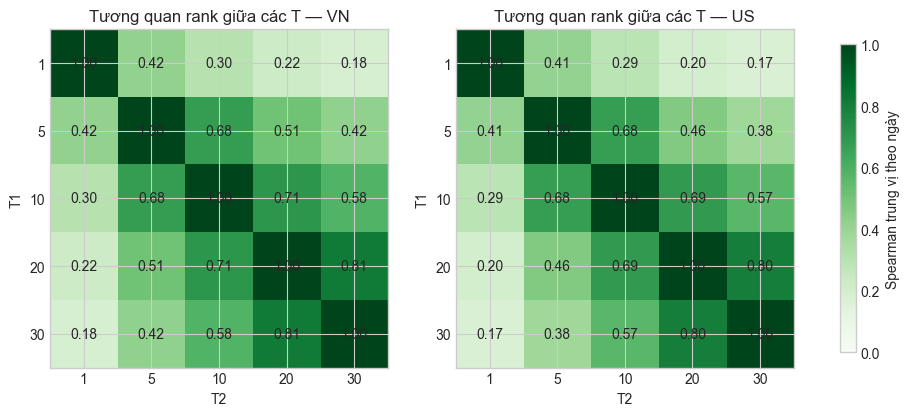

,Thị trường,T1,T2,Số ngày,Số mã/ngày trung vị,Spearman trung vị,Spearman Q25,Spearman Q75
0,US,1,1,1005,20.0000,1.0000,1.0000,1.0000
1,US,1,5,1001,20.0000,0.4120,0.2211,0.5805
2,US,1,10,996,20.0000,0.2857,0.0827,0.4962
3,US,1,20,986,20.0000,0.1970,0.0000,0.4090
4,US,1,30,976,20.0000,0.1707,-0.0436,0.3583
5,US,5,1,1001,20.0000,0.4120,0.2211,0.5805
6,US,5,5,1001,20.0000,1.0000,1.0000,1.0000
7,US,5,10,996,20.0000,0.6752,0.5361,0.7940
8,US,5,20,986,20.0000,0.4602,0.2771,0.6361
9,US,5,30,976,20.0000,0.3752,0.1910,0.5579


In [21]:
feature_ic_rows = []
for (market, date), day in PANEL_TRAIN.groupby(["Thị trường", "Date"]):
    for horizon in CONFIG["HORIZONS"]:
        target = f"FutureReturn_{horizon}"
        for feature in EDA_FEATURES:
            pair = day[[feature, target]].dropna()
            if len(pair) < 5 or pair[feature].nunique() < 2 or pair[target].nunique() < 2:
                continue
            feature_ic_rows.append({
                "Thị trường": market,
                "Date": date,
                "Năm": date.year,
                "T": horizon,
                "Feature": feature,
                "Số mã": len(pair),
                "Spearman IC": pair[feature].corr(pair[target], method="spearman"),
            })

FEATURE_IC_DAILY = pd.DataFrame(feature_ic_rows)
FEATURE_IC_SUMMARY = (
    FEATURE_IC_DAILY.groupby(["Thị trường", "T", "Feature"], as_index=False)
    .agg(
        **{
            "Số ngày": ("Date", "nunique"),
            "Số mã/ngày trung vị": ("Số mã", "median"),
            "IC trung vị": ("Spearman IC", "median"),
            "IC Q25": ("Spearman IC", lambda values: values.quantile(0.25)),
            "IC Q75": ("Spearman IC", lambda values: values.quantile(0.75)),
            "Tỷ lệ IC dương": ("Spearman IC", lambda values: values.gt(0).mean()),
        }
    )
)
FEATURE_IC_SUMMARY["IC IQR"] = FEATURE_IC_SUMMARY["IC Q75"] - FEATURE_IC_SUMMARY["IC Q25"]
FEATURE_IC_SUMMARY["Tỷ lệ ngày cùng dấu"] = np.maximum(
    FEATURE_IC_SUMMARY["Tỷ lệ IC dương"],
    1 - FEATURE_IC_SUMMARY["Tỷ lệ IC dương"],
)

FEATURE_IC_BY_YEAR = (
    FEATURE_IC_DAILY.groupby(["Thị trường", "T", "Năm", "Feature"], as_index=False)
    .agg(
        **{
            "Số ngày": ("Date", "nunique"),
            "IC trung vị": ("Spearman IC", "median"),
            "Tỷ lệ IC dương": ("Spearman IC", lambda values: values.gt(0).mean()),
        }
    )
)

for market in sorted(FEATURE_IC_SUMMARY["Thị trường"].unique()):
    print(f"Spearman IC trung vị theo ngày — {market}")
    display(
        FEATURE_IC_SUMMARY[FEATURE_IC_SUMMARY["Thị trường"].eq(market)]
        .pivot(index="Feature", columns="T", values="IC trung vị")
    )

future_columns = [f"FutureReturn_{horizon}" for horizon in CONFIG["HORIZONS"]]
target_rank_rows = []
for (market, date), day in PANEL_TRAIN.groupby(["Thị trường", "Date"]):
    matrix = day[future_columns].corr(method="spearman", min_periods=5)
    for first_t in CONFIG["HORIZONS"]:
        for second_t in CONFIG["HORIZONS"]:
            first = f"FutureReturn_{first_t}"
            second = f"FutureReturn_{second_t}"
            pair_count = len(day[[first, second]].dropna())
            value = matrix.loc[first, second]
            if pd.notna(value):
                target_rank_rows.append({
                    "Thị trường": market,
                    "Date": date,
                    "T1": first_t,
                    "T2": second_t,
                    "Số mã": pair_count,
                    "Spearman rank": value,
                })

TARGET_RANK_CORR_DAILY = pd.DataFrame(target_rank_rows)
TARGET_RANK_CORRELATIONS = (
    TARGET_RANK_CORR_DAILY.groupby(["Thị trường", "T1", "T2"], as_index=False)
    .agg(
        **{
            "Số ngày": ("Date", "nunique"),
            "Số mã/ngày trung vị": ("Số mã", "median"),
            "Spearman trung vị": ("Spearman rank", "median"),
            "Spearman Q25": ("Spearman rank", lambda values: values.quantile(0.25)),
            "Spearman Q75": ("Spearman rank", lambda values: values.quantile(0.75)),
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, market in zip(axes, ["VN", "US"]):
    matrix = (
        TARGET_RANK_CORRELATIONS[TARGET_RANK_CORRELATIONS["Thị trường"].eq(market)]
        .pivot(index="T1", columns="T2", values="Spearman trung vị")
        .reindex(index=CONFIG["HORIZONS"], columns=CONFIG["HORIZONS"])
    )
    image = axis.imshow(matrix.values, cmap="Greens", vmin=0, vmax=1)
    axis.set_xticks(range(len(matrix.columns)), matrix.columns)
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set(title=f"Tương quan rank giữa các T — {market}", xlabel="T2", ylabel="T1")
    for row_index in range(len(matrix.index)):
        for column_index in range(len(matrix.columns)):
            value = matrix.iloc[row_index, column_index]
            if pd.notna(value):
                axis.text(column_index, row_index, f"{value:.2f}", ha="center", va="center")

fig.colorbar(image, ax=axes, shrink=0.8, label="Spearman trung vị theo ngày")
plt.show()
display(TARGET_RANK_CORRELATIONS)


#### Nhận xét

Cross-sectional IC nhìn chung yếu: |IC trung vị| lớn nhất là 0,057 tại T=10 ở US và 0,053 tại T=20 ở VN. Rank của T=20 và T=30 trùng khá cao (0,799 ở US; 0,815 ở VN), trong khi T=10 và T=30 thấp hơn đáng kể (0,566; 0,583).


### 8.3. Độ ổn định theo năm và bảng shortlist T

Bảng cuối gom các tiêu chí mô tả quan trọng nhưng không tạo một điểm số tổng hợp tùy ý. Việc chọn T cần đồng thời cân nhắc coverage, spread, độ ổn định, sức mạnh IC và mức trùng lặp với T còn lại.


In [22]:
ic_strength_rows = []
for (market, horizon), group in FEATURE_IC_SUMMARY.groupby(["Thị trường", "T"]):
    strongest = group.loc[group["IC trung vị"].abs().idxmax()]
    ic_strength_rows.append({
        "Thị trường": market,
        "T": horizon,
        "Feature có |IC trung vị| lớn nhất": strongest["Feature"],
        "IC trung vị mạnh nhất": strongest["IC trung vị"],
        "|IC trung vị| lớn nhất": abs(strongest["IC trung vị"]),
        "Tỷ lệ ngày cùng dấu": strongest["Tỷ lệ ngày cùng dấu"],
    })
IC_HORIZON_STRENGTH = pd.DataFrame(ic_strength_rows)

selected_features = IC_HORIZON_STRENGTH[
    ["Thị trường", "T", "Feature có |IC trung vị| lớn nhất"]
].rename(columns={"Feature có |IC trung vị| lớn nhất": "Feature"})
IC_STABILITY_BY_YEAR = FEATURE_IC_BY_YEAR.merge(
    selected_features,
    on=["Thị trường", "T", "Feature"],
    how="inner",
)

redundancy_rows = []
for (market, horizon), group in TARGET_RANK_CORRELATIONS.groupby(["Thị trường", "T1"]):
    alternatives = group[group["T2"].ne(horizon)]
    closest = alternatives.loc[alternatives["Spearman trung vị"].idxmax()]
    redundancy_rows.append({
        "Thị trường": market,
        "T": horizon,
        "T tương đồng nhất": int(closest["T2"]),
        "Correlation rank cao nhất": closest["Spearman trung vị"],
    })
HORIZON_REDUNDANCY = pd.DataFrame(redundancy_rows)

HORIZON_DECISION_SUMMARY = (
    RANKING_TARGET_SUMMARY
    .merge(
        FEATURE_COVERAGE_BY_MARKET[["Thị trường", "T", "Coverage sử dụng"]],
        on=["Thị trường", "T"],
        how="left",
    )
    .merge(IC_HORIZON_STRENGTH, on=["Thị trường", "T"], how="left")
    .merge(HORIZON_REDUNDANCY, on=["Thị trường", "T"], how="left")
)

decision_columns = [
    "Thị trường",
    "T",
    "Số ngày ranking",
    "Số block thời gian xấp xỉ",
    "Số mã/ngày trung vị",
    "Coverage sử dụng",
    "P90-P10 trung vị",
    "Tỷ lệ giữ lại Top 20% trung vị",
    "Số ngày lịch trung vị",
    "Feature có |IC trung vị| lớn nhất",
    "IC trung vị mạnh nhất",
    "Tỷ lệ ngày cùng dấu",
    "T tương đồng nhất",
    "Correlation rank cao nhất",
]
HORIZON_DECISION_SUMMARY = HORIZON_DECISION_SUMMARY[decision_columns]

print("Độ phân tách target theo năm")
display(
    RANKING_STABILITY_BY_YEAR.pivot_table(
        index=["Thị trường", "Năm"], columns="T", values="P90-P10 trung vị"
    )
)
print("IC theo năm của feature mạnh nhất trên toàn kỳ Train")
display(
    IC_STABILITY_BY_YEAR.pivot_table(
        index=["Thị trường", "Năm"], columns="T", values="IC trung vị"
    )
)
print("Bảng tổng hợp phục vụ shortlist T")
display(HORIZON_DECISION_SUMMARY)


Độ phân tách target theo năm


T                   1      5      10     20     30
Thị trường Năm                                    
US         2020 0.0309 0.0690 0.1012 0.1557 0.2001
           2021 0.0255 0.0627 0.0927 0.1361 0.1685
           2022 0.0337 0.0813 0.1228 0.1646 0.2177
           2023 0.0297 0.0738 0.1151 0.1556 0.1946
VN         2020 0.0334 0.0783 0.1151 0.1760 0.2126
           2021 0.0372 0.0871 0.1308 0.2079 0.2590
           2022 0.0414 0.0938 0.1315 0.1821 0.2300
           2023 0.0279 0.0640 0.0944 0.1336 0.1744

IC theo năm của feature mạnh nhất trên toàn kỳ Train


T                    1       5       10      20      30
Thị trường Năm                                         
US         2020 -0.0632 -0.0279 -0.0421 -0.0707  0.0376
           2021  0.0000  0.0023 -0.0376  0.0074  0.1226
           2022  0.0241  0.0602  0.0767  0.0797  0.0677
           2023  0.0015 -0.1519 -0.2120 -0.2278 -0.0263
VN         2020 -0.0635 -0.0717  0.0258  0.0330  0.0210
           2021  0.0015  0.0285  0.1259  0.1264  0.1330
           2022 -0.0373 -0.0030  0.0388 -0.1007 -0.1517
           2023 -0.0219 -0.0071 -0.1079  0.0621  0.0818

Bảng tổng hợp phục vụ shortlist T


,Thị trường,T,Số ngày ranking,Số block thời gian xấp xỉ,Số mã/ngày trung vị,Coverage sử dụng,P90-P10 trung vị,Tỷ lệ giữ lại Top 20% trung vị,Số ngày lịch trung vị,Feature có |IC trung vị| lớn nhất,IC trung vị mạnh nhất,Tỷ lệ ngày cùng dấu,T tương đồng nhất,Correlation rank cao nhất
0,US,1,1005,1005,20.0000,0.9503,0.0296,0.2500,1.0000,Return_1D,-0.0165,0.5179,5,0.4120
1,US,5,1001,201,20.0000,0.9463,0.0713,0.7500,7.0000,Drawdown,-0.0331,0.5300,10,0.6752
2,US,10,996,100,20.0000,0.9414,0.1059,0.7500,14.0000,Drawdown,-0.0571,0.5548,20,0.6887
3,US,20,986,50,20.0000,0.9314,0.1547,0.7500,29.0000,Drawdown,-0.0406,0.5584,30,0.7992
4,US,30,976,33,20.0000,0.9215,0.1974,0.7500,43.0000,Price_vs_MA50,0.0481,0.5663,20,0.7992
5,VN,1,965,965,29.0000,0.9457,0.0339,0.1667,1.0000,Price_vs_MA20,-0.0289,0.5307,5,0.4160
6,VN,5,961,193,29.0000,0.9414,0.0794,0.6667,7.0000,Return_5D,-0.0244,0.5387,10,0.6793
7,VN,10,956,96,29.0000,0.9360,0.1153,0.8000,14.0000,Drawdown,0.0365,0.5382,20,0.7066
8,VN,20,946,48,29.0000,0.9251,0.1723,0.8333,29.0000,Price_vs_MA50,0.0532,0.5641,30,0.8146
9,VN,30,936,32,29.0000,0.9143,0.2185,0.8333,44.0000,Price_vs_MA50,0.0415,0.5502,20,0.8146


#### Nhận xét

T=10 và T=30 là cặp common T hợp lý để đưa vào shortlist: T=10 giữ coverage cao và T=30 có target spread lớn hơn, trong khi correlation rank giữa hai T chỉ ở mức trung bình. Đây vẫn là shortlist từ EDA vì IC còn yếu, thay đổi dấu theo năm và T=30 chỉ có khoảng 32–33 block thời gian gần độc lập ở mỗi thị trường.


## 9. Xuất bảng kết quả gọn

Notebook xuất một workbook gồm các bảng EDA chính, bao gồm các bảng cross-sectional dùng để shortlist T. Biểu đồ được giữ trong notebook, không tạo hàng trăm file PNG.


In [23]:
SELECTED_DESCRIPTIVE = (
    TRAIN[
        [
            "Adj Close",
            "Volume",
            "Return_1D",
            "Return_5D",
            "Return_20D",
            "Volatility_20_Ann",
            "RVOL",
            "Drawdown",
        ]
    ]
    .describe()
    .T
    .reset_index(names="Biến")
)

REPORT_PATH = OUTPUT_DIR / "Stock_EDA_Summary.xlsx"
with pd.ExcelWriter(REPORT_PATH, engine="xlsxwriter") as writer:
    ALL_DATA_QUALITY.to_excel(writer, sheet_name="Data_Quality", index=False)

    selected_quality_frame = pd.DataFrame([SELECTED_QUALITY])
    selected_quality_frame.to_excel(writer, sheet_name="Selected_Stock_EDA", index=False, startrow=0)
    SELECTED_DESCRIPTIVE.to_excel(
        writer,
        sheet_name="Selected_Stock_EDA",
        index=False,
        startrow=len(selected_quality_frame) + 3,
    )
    ANNUAL_STATS.to_excel(
        writer,
        sheet_name="Selected_Stock_EDA",
        index=False,
        startrow=len(selected_quality_frame) + len(SELECTED_DESCRIPTIVE) + 6,
    )
    ZERO_VOLUME_DATES.to_excel(
        writer,
        sheet_name="Selected_Stock_EDA",
        index=False,
        startrow=len(selected_quality_frame) + len(SELECTED_DESCRIPTIVE) + len(ANNUAL_STATS) + 9,
    )

    HORIZON_SUMMARY.to_excel(writer, sheet_name="Horizon_Summary", index=False, startrow=0)
    HORIZON_BY_YEAR.to_excel(
        writer,
        sheet_name="Horizon_Summary",
        index=False,
        startrow=len(HORIZON_SUMMARY) + 3,
    )

    ALL_STOCKS_SUMMARY.to_excel(writer, sheet_name="All_Stocks_Summary", index=False, startrow=0)
    MARKET_COMPARISON.to_excel(
        writer,
        sheet_name="All_Stocks_Summary",
        index=False,
        startrow=len(ALL_STOCKS_SUMMARY) + 3,
    )

    MARKET_HORIZON_SUMMARY.to_excel(writer, sheet_name="Market_Horizons", index=False, startrow=0)
    MARKET_HORIZON_BY_YEAR.to_excel(
        writer, sheet_name="Market_Horizons", index=False, startrow=len(MARKET_HORIZON_SUMMARY) + 3
    )

    FEATURE_COVERAGE.to_excel(writer, sheet_name="Feature_Coverage", index=False, startrow=0)
    FEATURE_COVERAGE_BY_MARKET.to_excel(
        writer, sheet_name="Feature_Coverage", index=False, startrow=len(FEATURE_COVERAGE) + 3
    )

    LABEL_BALANCE_SUMMARY.to_excel(writer, sheet_name="Label_Overlap", index=False, startrow=0)
    LABEL_BALANCE.to_excel(
        writer, sheet_name="Label_Overlap", index=False, startrow=len(LABEL_BALANCE_SUMMARY) + 3
    )
    OVERLAP_SUMMARY.to_excel(
        writer, sheet_name="Label_Overlap", index=False,
        startrow=len(LABEL_BALANCE_SUMMARY) + len(LABEL_BALANCE) + 6,
    )

    UNIVERSE_SUMMARY.to_excel(writer, sheet_name="Ranking_Profile", index=False, startrow=0)
    RANKING_TARGET_SUMMARY.to_excel(
        writer, sheet_name="Ranking_Profile", index=False, startrow=len(UNIVERSE_SUMMARY) + 3
    )
    RANKING_STABILITY_BY_YEAR.to_excel(
        writer,
        sheet_name="Ranking_Profile",
        index=False,
        startrow=len(UNIVERSE_SUMMARY) + len(RANKING_TARGET_SUMMARY) + 6,
    )

    FEATURE_IC_SUMMARY.to_excel(writer, sheet_name="Ranking_IC", index=False, startrow=0)
    FEATURE_IC_BY_YEAR.to_excel(
        writer, sheet_name="Ranking_IC", index=False, startrow=len(FEATURE_IC_SUMMARY) + 3
    )
    IC_STABILITY_BY_YEAR.to_excel(
        writer,
        sheet_name="Ranking_IC",
        index=False,
        startrow=len(FEATURE_IC_SUMMARY) + len(FEATURE_IC_BY_YEAR) + 6,
    )

    HORIZON_DECISION_SUMMARY.to_excel(writer, sheet_name="T_Decision", index=False, startrow=0)
    TARGET_RANK_CORRELATIONS.to_excel(
        writer,
        sheet_name="T_Decision",
        index=False,
        startrow=len(HORIZON_DECISION_SUMMARY) + 3,
    )

print(f"Đã xuất báo cáo: {REPORT_PATH}")


Đã xuất báo cáo: C:\Users\Hoang Phu\Downloads\HCMUT\Final Year\P4AI&DS\BTL\P4AIDS---Stock\outputs\Stock_EDA_Summary.xlsx


## 10. Kiểm tra logic tối thiểu

Các assert ngắn xác nhận những điều kiện quan trọng, không xây dựng một test framework riêng.

In [24]:
assert SELECTED["Date"].is_monotonic_increasing, "Ngày chưa tăng dần."
assert not SELECTED["Date"].duplicated().any(), "Vẫn còn ngày trùng."
assert (SELECTED[PRICE_COLUMNS] > 0).all().all(), "Vẫn còn giá không dương."
assert (SELECTED["Volume"] > 0).all(), "Vẫn còn volume không dương."

for horizon in CONFIG["HORIZONS"]:
    assert SELECTED_WITH_TARGETS[f"FutureReturn_{horizon}"].tail(horizon).isna().all()
    valid = SELECTED_WITH_TARGETS[f"FutureReturn_{horizon}"].notna()
    same_split = SELECTED_WITH_TARGETS["Split"].eq(
        SELECTED_WITH_TARGETS["Split"].shift(-horizon)
    )
    assert same_split[valid].all(), f"Target T={horizon} vượt biên split."

assert np.allclose(
    HORIZON_SUMMARY["P(UP)"] + HORIZON_SUMMARY["P(DOWN)"],
    1,
    equal_nan=True,
), "P(UP) và P(DOWN) không cộng thành 1."

altered = SELECTED_CLEAN.copy()
altered.loc[altered.index[-1], "Adj Close"] *= 10
features_before = add_features(SELECTED_CLEAN)
features_after = add_features(altered)
past_columns = ["MA20", "MA50", "Price_vs_MA20", "Price_vs_MA50", "Volatility_20_Ann", "Volume_MA20"]
assert features_before.iloc[:-1][past_columns].equals(
    features_after.iloc[:-1][past_columns]
), "Feature quá khứ bị ảnh hưởng bởi dữ liệu tương lai."

assert RANKING_TARGET_SUMMARY["Số mã/ngày nhỏ nhất"].ge(5).all()
assert RANKING_TARGET_SUMMARY["Số ngày lịch trung vị"].gt(0).all()
assert FEATURE_IC_DAILY["Spearman IC"].between(-1, 1).all()
assert TOP_GROUP_DAILY["Tỷ lệ giữ lại Top 20%"].between(0, 1).all()

print("PASS: dữ liệu sạch, target không vượt biên split và các bảng ranking hợp lệ.")

PASS: dữ liệu sạch, target không vượt biên split và các bảng ranking hợp lệ.


In [25]:
KEY_FINDINGS = pd.DataFrame({
    "Chỉ tiêu": [
        "Số quan sát Train",
        "Return ngày trung bình",
        "Volatility 20 phiên trung vị",
        "Maximum drawdown",
        "Correlation |return| và relative volume",
        "P(UP) thấp nhất trong các T",
        "P(UP) cao nhất trong các T",
    ],
    "Giá trị": [
        len(TRAIN),
        TRAIN["Return_1D"].mean(),
        TRAIN["Volatility_20_Ann"].median(),
        MAX_DRAWDOWN,
        VOLUME_RETURN_CORRELATION,
        HORIZON_SUMMARY["P(UP)"].min(),
        HORIZON_SUMMARY["P(UP)"].max(),
    ],
})

display(KEY_FINDINGS)

,Chỉ tiêu,Giá trị
0,Số quan sát Train,960.0000
1,Return ngày trung bình,0.0014
2,Volatility 20 phiên trung vị,0.2337
3,Maximum drawdown,-0.3106
4,Correlation |return| và relative volume,0.2190
5,P(UP) thấp nhất trong các T,0.5036
6,P(UP) cao nhất trong các T,0.6753


## 11. Cách diễn giải và hạn chế

- Các kết quả là mô tả lịch sử, không phải dự báo hay khuyến nghị đầu tư.
- Mỗi ngày trong từng thị trường là một nhóm ranking; số stock-date không được xem là số quan sát ranking độc lập.
- Return nhiều phiên chồng lấn nên các ngày ranking liên tiếp không độc lập hoàn toàn.
- `P(UP)` là thống kê phụ, không trực tiếp đo khả năng xếp hạng công ty.
- `Adj Close` là dữ liệu điều chỉnh hồi cứu và có thể không hoàn toàn point-in-time.
- Danh sách cổ phiếu hiện tại và universe động có thể tạo survivorship bias khi phân tích lịch sử.
- Mẫu VN30 và 20 mã Nasdaq không đại diện cho toàn bộ hai thị trường.
- Nếu xếp hạng chung VN và US trong cùng một nhóm, cần xử lý thêm múi giờ, ngày giao dịch, benchmark và tiền tệ; notebook hiện phân tích ranking riêng trong từng thị trường.
- Toàn bộ bảng EDA panel sử dụng Train; Validation và Test không được dùng để kết luận về T.
